In [1]:
import os
import sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append("../")
from src.io import read_parameters
from griottes import generate_delaunay_graph
import networkx as nx



cmap = matplotlib.colormaps["seismic_r"]

In [2]:
# read parameters and key file

parameter_file = "/home/jpa/PycharmProjects/ec-tracking-analysis_2025/data/collectivity/parameters_collectivity.yml"
parameters = read_parameters(parameter_file)       

key_file_path = parameters["key_file"]
key_file = pd.read_csv(key_file_path)

print("key file columns:", key_file.columns)
print("key file conditions:", key_file["condition"].unique())

key file columns: Index(['experimentID', 'filename', 'color', 'treatment', 'condition',
       'frame_per_hour', 'date'],
      dtype='object')
key file conditions: ['control' 'kank']


In [3]:
# create output folder

output_folder = Path(parameters["output_folder"])
print("Output folder:", output_folder)

data_folder = output_folder.joinpath("tracking_data")

subfolder = "time_graph_analysis"
if not os.path.exists(output_folder.joinpath(subfolder)):
    os.mkdir(output_folder.joinpath(subfolder))

Output folder: /home/jpa/PycharmProjects/ec-tracking-analysis_2025/data/collectivity/collectivityquestion_results


In [4]:
# plot paramters

#condition = 'mosaic_siCTRL_siAlk1'
#condition = 'mosaic_siCTRL_siSMAD4'
# color = 'red'
#treatment = 'siAlk1'

#number_of_tracks_per_condition = 1000

observation_time = parameters["observation_time"]

# limits for min velocity and max velocity in um/h used for the color map
min_vel_lim = -20.0 # um/h
max_vel_lim = 20.0 # um/h

# extend in microns of the coordinate system used for plotting, 
# range is [-max_x, max_x] in x direction and [-max_y, max_y] in y direction
max_x = 600 # um
max_y = 600 # um

obs_time_length_frames = observation_time[1] - observation_time[0]

print("Observation time (frames):", observation_time)

plot_tracks = False
plot_arrows = True

distance_threshold = parameters.get("distance_threshold", 50) # um, default value if not specified in parameters

Observation time (frames): [0, 50]


In [5]:
num_subsample = 5

In [6]:
graphs = {}
observation_period_dfs = {}
# loop over all experiments 
for experimentID in key_file["experimentID"].unique():
    print("Processing experiment:", experimentID)

    # can only be one entry
    key_exp = key_file[key_file["experimentID"] == experimentID]

    row = key_exp.iloc[0]
    treatment = row["treatment"]

    tracking_file = "tracking_data_%s_%s_%s.csv" % (treatment, row["color"], row["experimentID"])
    data = pd.read_csv(str(data_folder.joinpath(tracking_file)), low_memory=False)

    # filter data for observation period
    observation_period_df = data[data["FRAME"] <= observation_time[1]]
    observation_period_df = observation_period_df[observation_period_df["FRAME"] >= observation_time[0]]
    observation_period_dfs[experimentID] = observation_period_df

    # rename columns for G_delaunay graph generation
    observation_period_df_exp = observation_period_df.rename(columns={"POSITION_X": "x", "POSITION_Y": "y"})
    # add "label" column
    observation_period_df_exp["label"] = observation_period_df_exp["TRACK_ID"]

    t_graphs = []

    # build G_delaunay graph per point in time
    for t in range(observation_time[0], observation_time[1]):
        observation_period_df_exp_id_t = observation_period_df_exp[observation_period_df_exp["FRAME"] == t].reset_index(drop=True)

        #print(observation_period_df_exp_id_t[["FRAME", "TRACK_ID", "label"]].head())

        print("Generating graph at time point %d ..." % t)
        G_delaunay = generate_delaunay_graph(
            observation_period_df_exp_id_t[observation_period_df_exp_id_t.columns],
            descriptors=observation_period_df_exp_id_t.columns,
            distance=distance_threshold,
            image_is_2D=True
        )
        print("Graph generated!")

        # relabel nodes to TRACK_IDs
        mapping = {n: G_delaunay.nodes[n]["TRACK_ID"] for n in G_delaunay.nodes}
        G_delaunay = nx.relabel_nodes(G_delaunay, mapping)

        t_graphs.append(G_delaunay)

    # store graphs for this experiment (using experimentID for now, will map to condition later)
    graphs[experimentID] = t_graphs

Processing experiment: S1_rep1
Generating graph at time point 0 ...
Graph generated!
Generating graph at time point 1 ...
Graph generated!
Generating graph at time point 2 ...
Graph generated!
Generating graph at time point 3 ...
Graph generated!
Generating graph at time point 4 ...
Graph generated!
Generating graph at time point 5 ...
Graph generated!
Generating graph at time point 6 ...
Graph generated!
Generating graph at time point 7 ...
Graph generated!
Generating graph at time point 8 ...
Graph generated!
Generating graph at time point 9 ...
Graph generated!
Generating graph at time point 10 ...
Graph generated!
Generating graph at time point 11 ...
Graph generated!
Generating graph at time point 12 ...
Graph generated!
Generating graph at time point 13 ...
Graph generated!
Generating graph at time point 14 ...
Graph generated!
Generating graph at time point 15 ...
Graph generated!
Generating graph at time point 16 ...
Graph generated!
Generating graph at time point 17 ...
Graph 


=== Visualizing condition: control ===
  Processing experiment 1/3: S1_rep1

--- Node 123 Trajectory Summary ---
Number of timepoints: 50
Time range (frames): 0 to 49
X range (μm): 916.0 to 951.0
Y range (μm): 999.0 to 1017.0
Total displacement (μm): 5.1
Average neighbors per frame: N/A (show_neighbors=False)
-----------------------------------



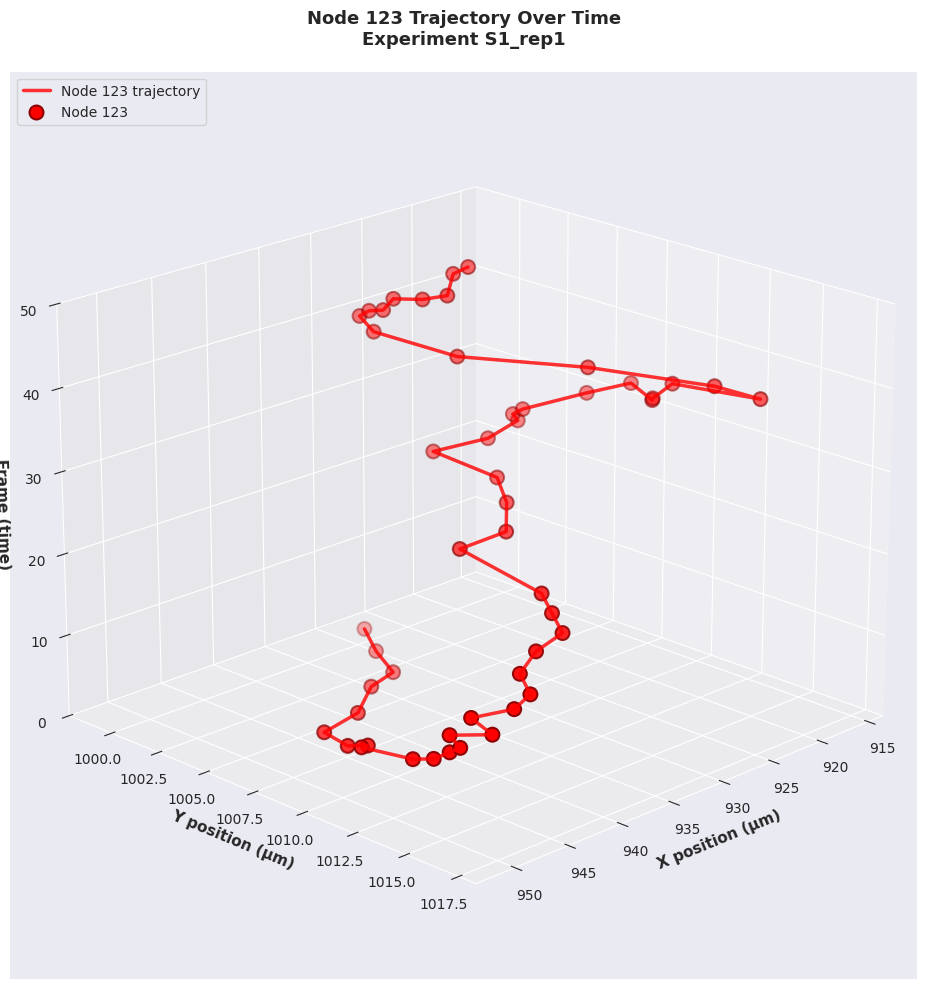

  Processing experiment 2/3: S1_rep2

--- Node 123 Trajectory Summary ---
Number of timepoints: 50
Time range (frames): 0 to 49
X range (μm): 2025.0 to 2102.0
Y range (μm): 2378.0 to 2396.0
Total displacement (μm): 77.4
Average neighbors per frame: N/A (show_neighbors=False)
-----------------------------------



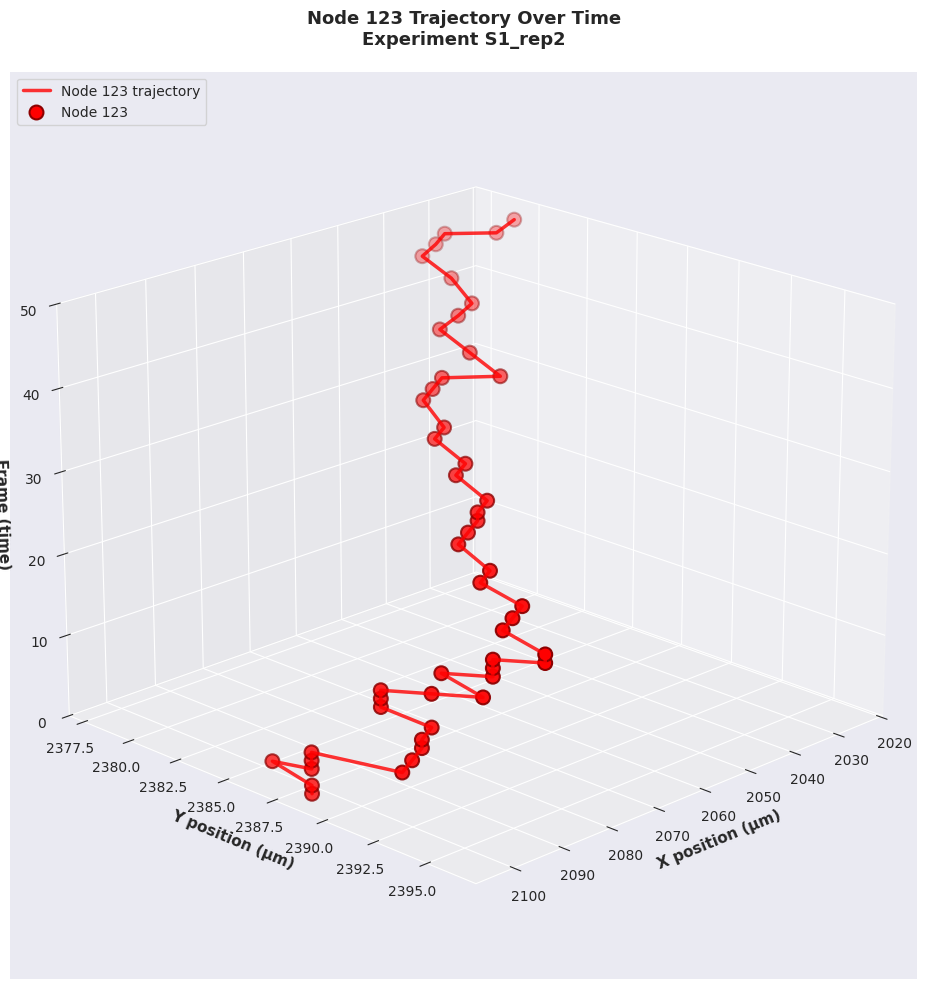

  Processing experiment 3/3: S1_rep3

--- Node 123 Trajectory Summary ---
Number of timepoints: 38
Time range (frames): 0 to 37
X range (μm): 2232.0 to 2286.0
Y range (μm): 760.5 to 782.5
Total displacement (μm): 52.0
Average neighbors per frame: 0.0
-----------------------------------



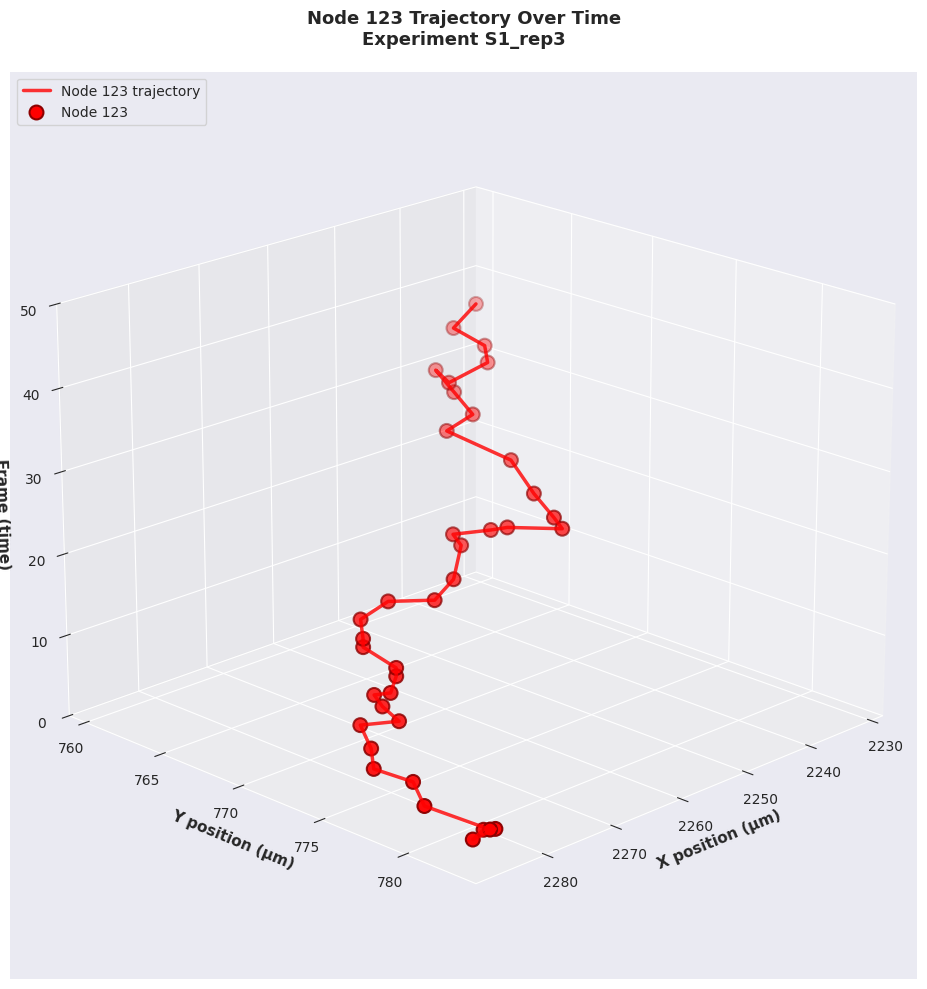


=== Visualizing condition: kank ===
  Processing experiment 1/3: K1_rep1

--- Node 123 Trajectory Summary ---
Number of timepoints: 50
Time range (frames): 0 to 49
X range (μm): 1478.0 to 1557.0
Y range (μm): 281.2 to 295.0
Total displacement (μm): 28.2
Average neighbors per frame: N/A (show_neighbors=False)
-----------------------------------



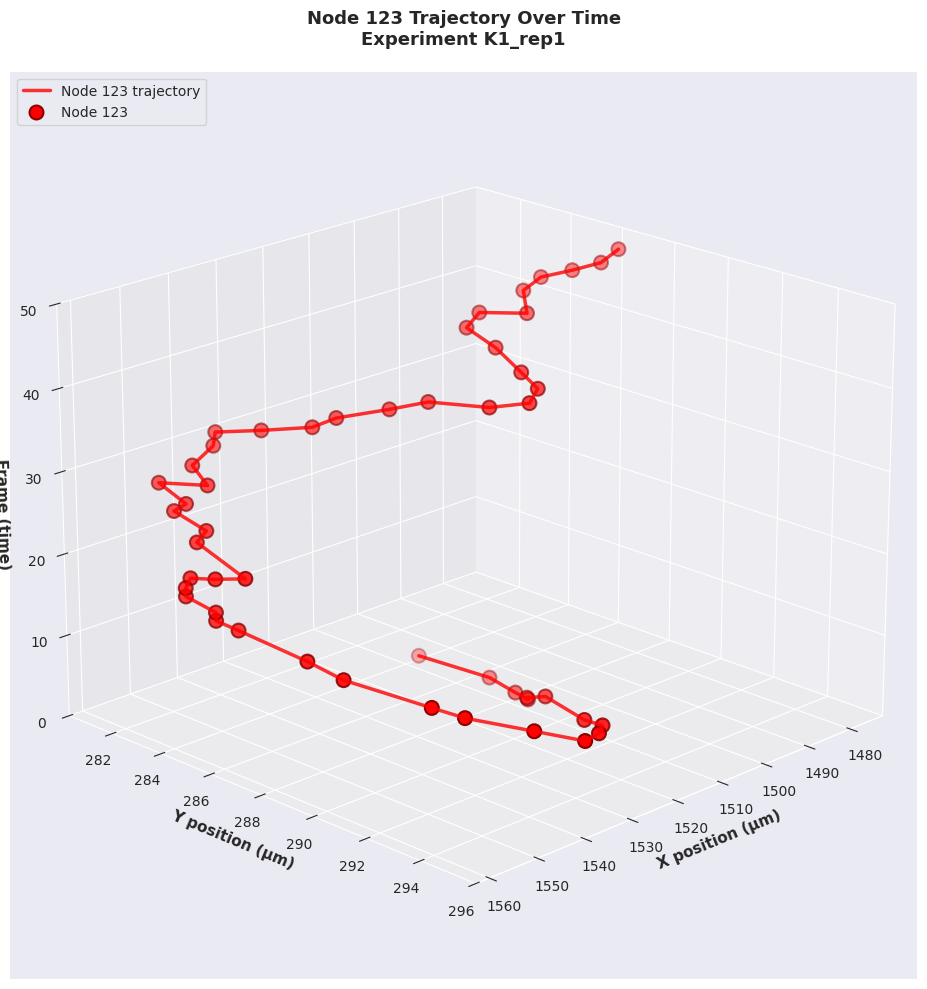

  Processing experiment 2/3: K1_rep2

--- Node 123 Trajectory Summary ---
Number of timepoints: 50
Time range (frames): 0 to 49
X range (μm): 2586.0 to 2624.0
Y range (μm): 112.6 to 176.0
Total displacement (μm): 66.7
Average neighbors per frame: N/A (show_neighbors=False)
-----------------------------------



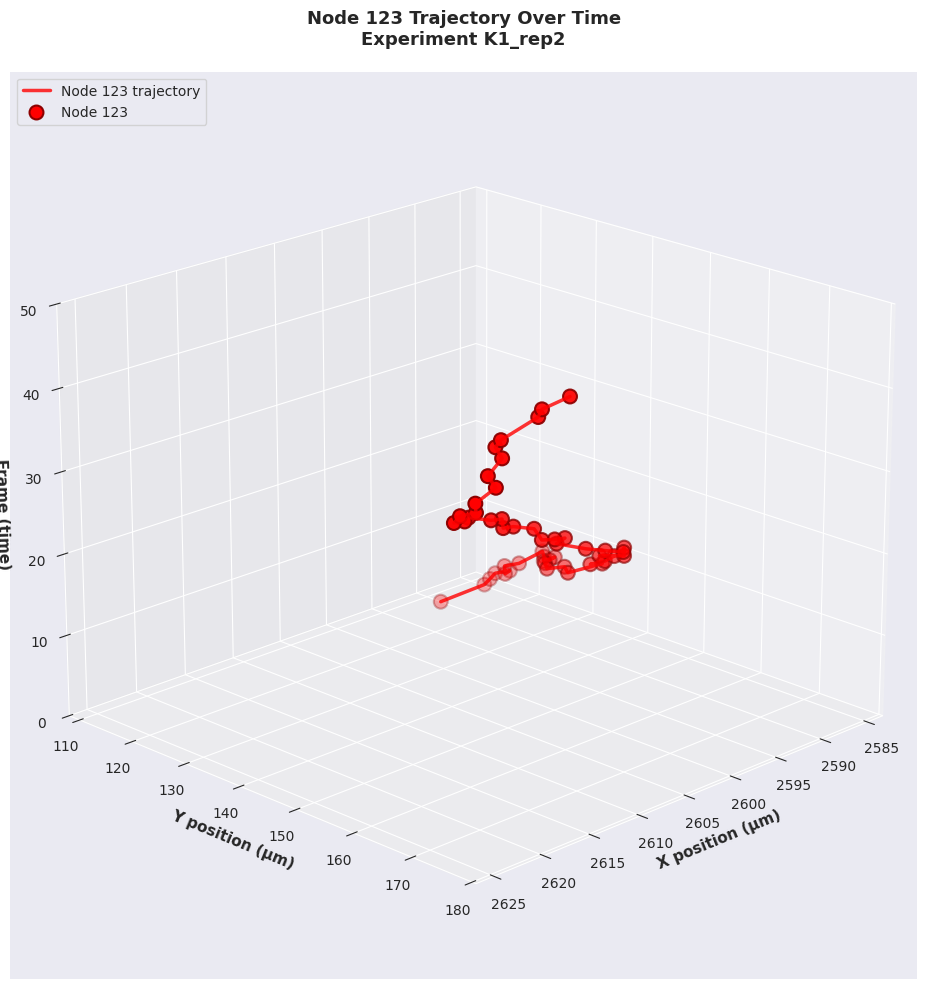

  Processing experiment 3/3: K1_rep3

--- Node 123 Trajectory Summary ---
Number of timepoints: 50
Time range (frames): 0 to 49
X range (μm): 483.8 to 585.0
Y range (μm): 1175.0 to 1203.0
Total displacement (μm): 81.9
Average neighbors per frame: N/A (show_neighbors=False)
-----------------------------------



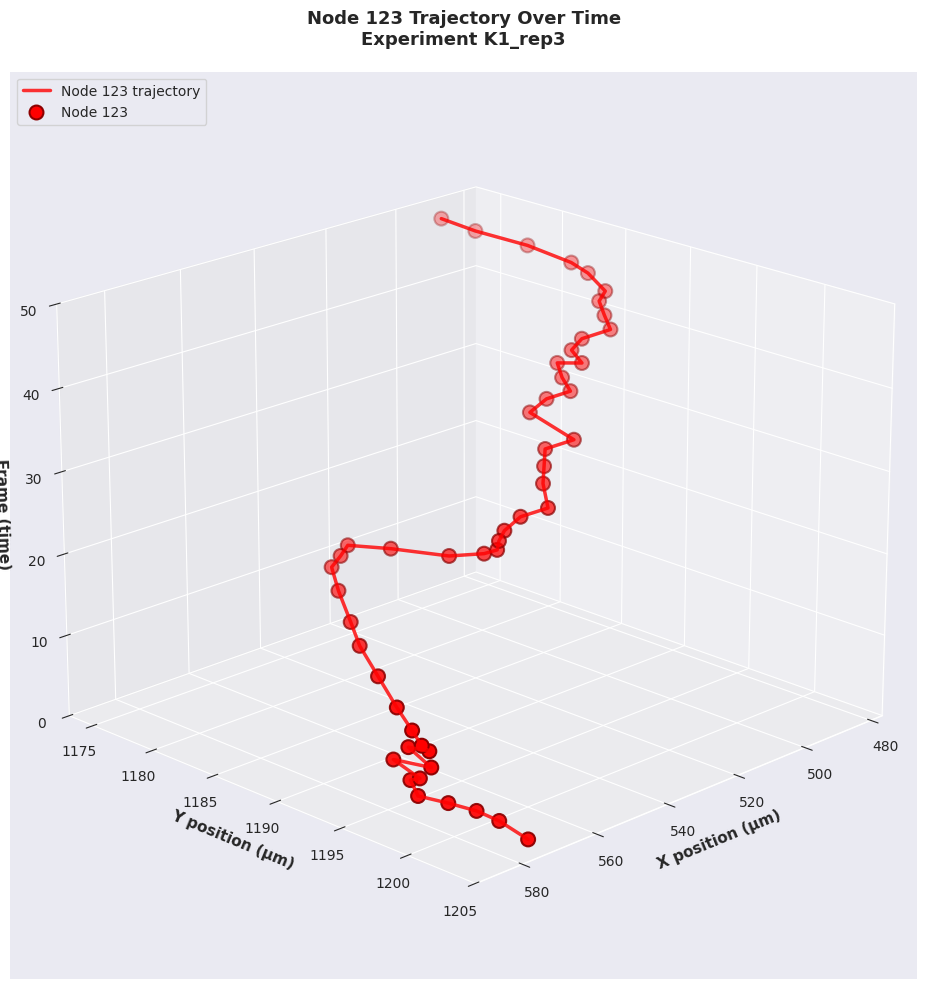

In [7]:
from src.node_trajectory_viz import plot_node_trajectory_3d

# Choose a node ID to track (must be a TRACK_ID that exists in your graphs)
node_to_track = 123  # Replace with your desired node ID

# Visualize node trajectory for each experiment (organized by condition)
for condition in key_file["condition"].unique():
    print(f"\n=== Visualizing condition: {condition} ===")
    
    # Get all experiments for this condition
    experiments_for_condition = key_file[key_file["condition"] == condition]
    
    for idx, (_, row) in enumerate(experiments_for_condition.iterrows()):
        experimentID = row["experimentID"]
        print(f"  Processing experiment {idx+1}/{len(experiments_for_condition)}: {experimentID}")
        
        if experimentID not in graphs:
            print(f"    Skipping - no graphs for {experimentID}")
            continue
        
        # Generate the visualization
        fig, ax = plot_node_trajectory_3d(
            node_id=node_to_track,
            graphs=graphs,                    # from previous cell
            experimentID=experimentID,        # which experiment to visualize
            observation_time=observation_time, # frame range from parameters
            figsize=(14, 10),
            node_color='red',
            neighbor_color='lightblue',
            neighbor_alpha=0.35,
            trajectory_linewidth=2.5,
            show_neighbors=False,
        )

        plt.show()

In [8]:
neighbor_lifetimes_by_condition = {}

# iterate over conditions
for condition in key_file["condition"].unique():
    print(f"\nAnalyzing condition: {condition}")
    
    # Get all experiments for this condition
    experiments_for_condition = key_file[key_file["condition"] == condition]
    
    # Aggregate neighbor lifetimes across all experiments in this condition
    neighbor_lifetimes_all_tracks = {}
    
    for _, row in experiments_for_condition.iterrows():
        experimentID = row["experimentID"]
        print(f"  Processing experiment: {experimentID}")
        
        if experimentID not in observation_period_dfs:
            print(f"    Skipping - no data for {experimentID}")
            continue
        
        observation_period_df = observation_period_dfs[experimentID]
        
        if experimentID not in graphs:
            print(f"    Skipping - no graphs for {experimentID}")
            continue
        
        # get time graphs for this experiment
        t_graphs = graphs[experimentID]
        
        # iterate over sampled tracks
        trackIDs = observation_period_df["TRACK_ID"].unique()
        
        for track_id in trackIDs:
            neighbor_lifetimes = {}

            # first time point
            t_graphs0 = t_graphs[0]

            if track_id not in t_graphs0.nodes(data="TRACK_ID"):
                continue

            neighbors0 = list(t_graphs0.neighbors(track_id))

            for neighbor in neighbors0:
                neighbor_lifetimes[neighbor] = 1  # initialize lifetimes at time 0

            # iterate over rest of time points
            for t, G_delaunay in enumerate(t_graphs[1:], start=1):

                # iterate
                node_track = [n for n, d in G_delaunay.nodes(data=True) if d.get("TRACK_ID") == track_id]
                if len(node_track) > 1:
                    continue
                elif len(node_track) == 0:
                    break

                a = node_track[0]
                neighbors_t = G_delaunay[a]

                # increment lifetime count for each observed neighbor
                for neighbor in neighbors_t:
                    if neighbor in neighbor_lifetimes:
                        # increment only if consecutive
                        if neighbor_lifetimes[neighbor] == t:
                            neighbor_lifetimes[neighbor] += 1

            neighbor_lifetimes_all_tracks[track_id] = neighbor_lifetimes
    
    neighbor_lifetimes_by_condition[condition] = neighbor_lifetimes_all_tracks


Analyzing condition: control
  Processing experiment: S1_rep1
  Processing experiment: S1_rep2
  Processing experiment: S1_rep3

Analyzing condition: kank
  Processing experiment: K1_rep1
  Processing experiment: K1_rep2
  Processing experiment: K1_rep3



Condition: control
Sampled 5 track IDs: [4096 3163 2952 3324 3086]
Edge lifetimes for track ID 4096: [4, 3, 19, 16]


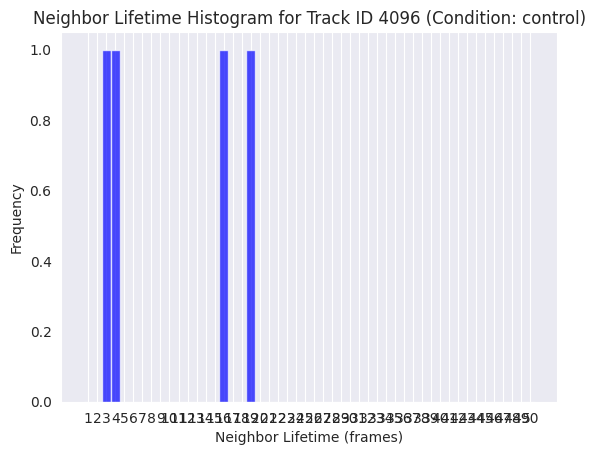

Edge lifetimes for track ID 3163: [27, 8, 27]


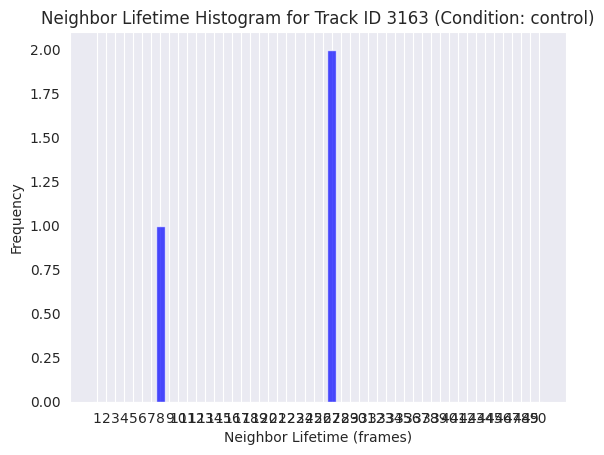

Edge lifetimes for track ID 2952: [9, 9, 6]


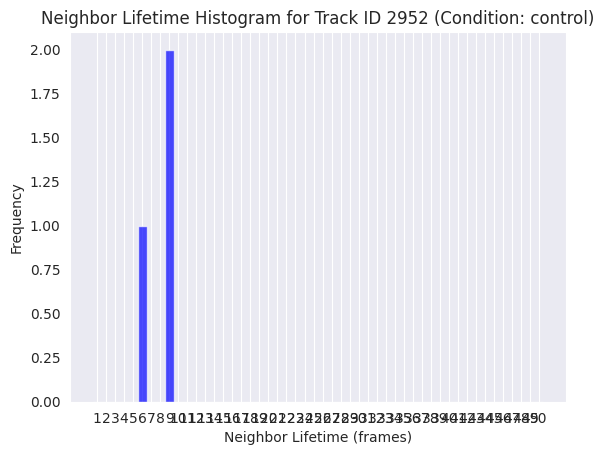

Edge lifetimes for track ID 3324: [25, 32, 14]


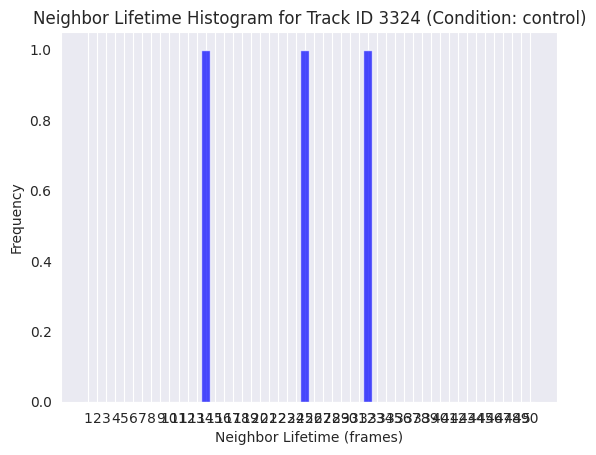

Edge lifetimes for track ID 3086: [12, 31, 1, 44]


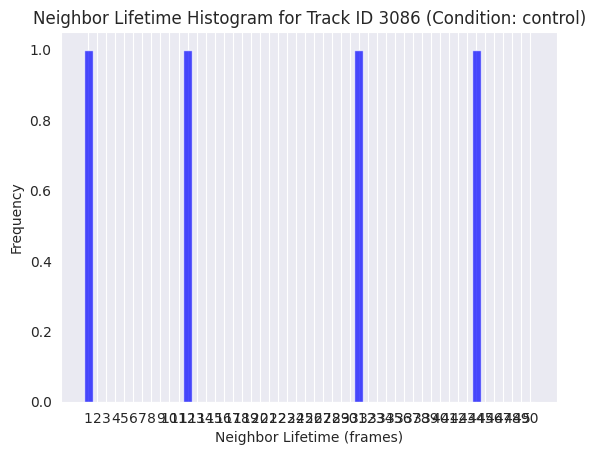


Condition: kank
Sampled 5 track IDs: [3309 2765 3041 2000  561]
Edge lifetimes for track ID 3309: [8, 3, 9, 2]


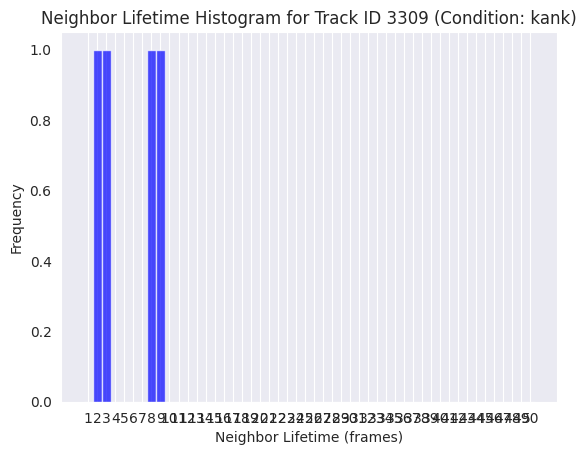

Edge lifetimes for track ID 2765: [2, 19]


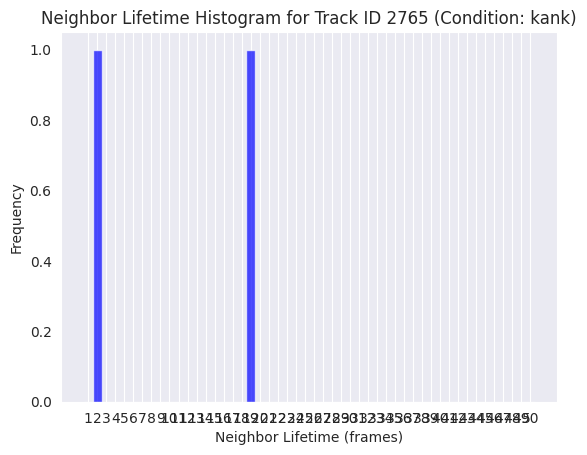

Edge lifetimes for track ID 3041: [6, 8, 1]


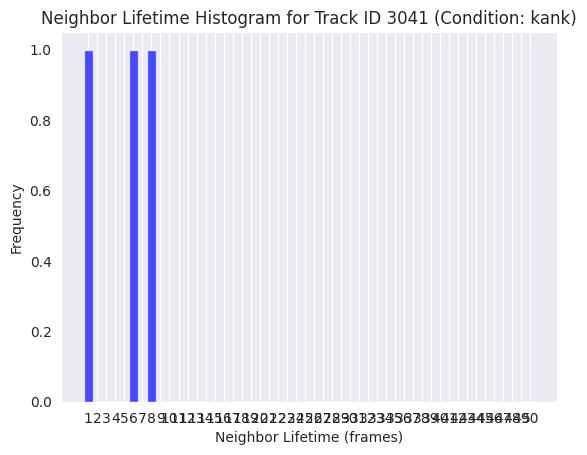

Edge lifetimes for track ID 2000: [4]


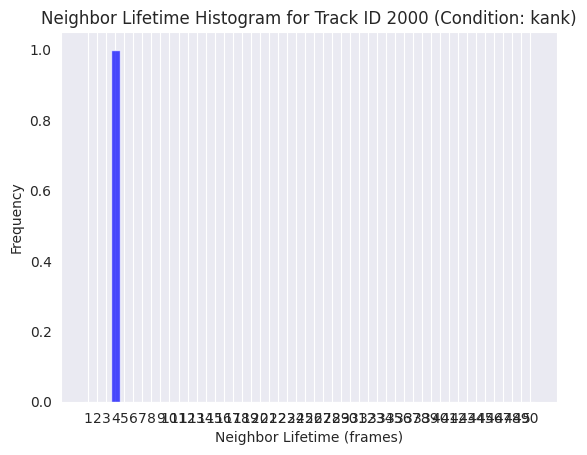

Edge lifetimes for track ID 561: [10, 20]


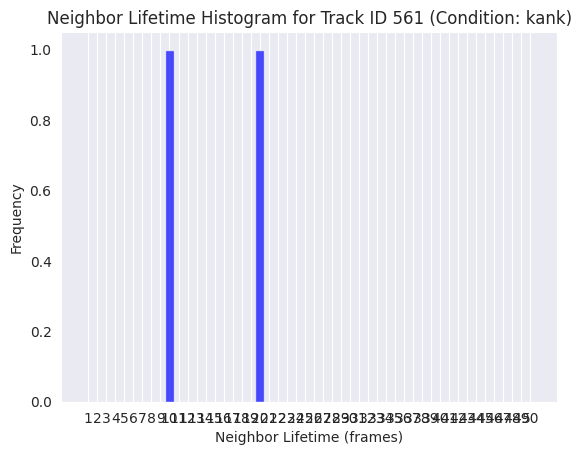

In [9]:
# randomly sample some tracks and plot histograms of neighbor lifetimes
for condition in key_file["condition"].unique():
    print(f"\nCondition: {condition}")

    neighbor_lifetimes_tracks = neighbor_lifetimes_by_condition[condition]

    trackIDs = list(neighbor_lifetimes_tracks.keys())

    if len(trackIDs) > num_subsample:
        sampled_trackIDs = np.random.choice(trackIDs, size=num_subsample, replace=False)
    else:
        sampled_trackIDs = trackIDs

    print(f"Sampled {len(sampled_trackIDs)} track IDs:", sampled_trackIDs)

    for track_id in sampled_trackIDs:
        neighbor_lifetimes = neighbor_lifetimes_tracks[track_id]

        lifetimes = list(neighbor_lifetimes.values())

        print(f"Edge lifetimes for track ID {track_id}:", lifetimes)

        plt.figure()
        plt.hist(lifetimes, bins=range(1, obs_time_length_frames + 2),
                 align='left', color='blue', alpha=0.7)
        plt.xlabel('Neighbor Lifetime (frames)')
        plt.ylabel('Frequency')
        plt.title(f'Neighbor Lifetime Histogram for Track ID {track_id} (Condition: {condition})')
        plt.xticks(range(1, obs_time_length_frames + 1))
        plt.grid(axis='y')
        plt.show()


Condition: control
Mean Neighbor Lifetime: 18.72 frames
Median Neighbor Lifetime: 14.00 frames
Standard Deviation: 15.24 frames

Condition: kank
Mean Neighbor Lifetime: 18.05 frames
Median Neighbor Lifetime: 14.00 frames
Standard Deviation: 14.59 frames


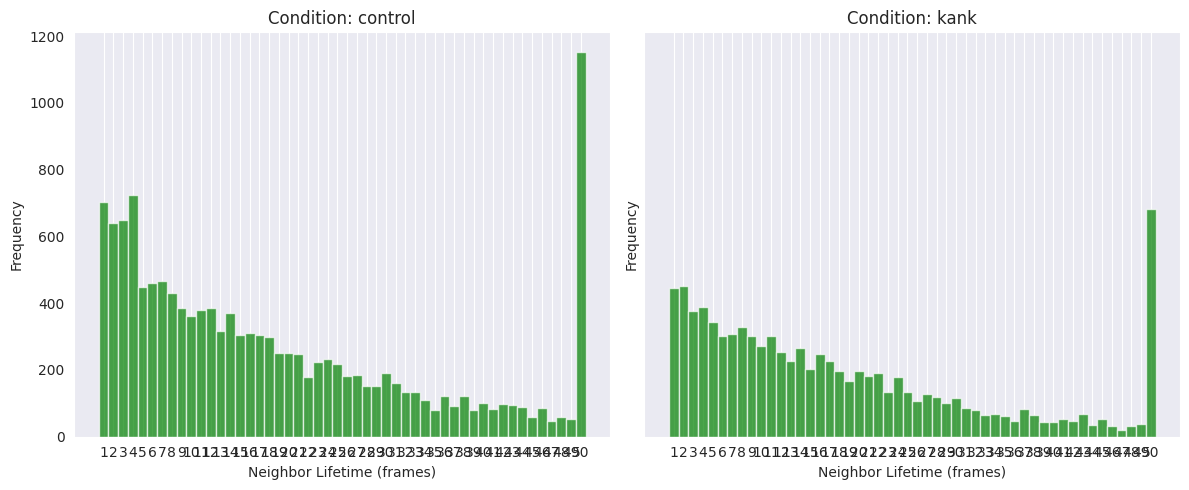

In [10]:
# summary stats of neighbor lifetimes across all tracks
conditions = key_file["condition"].unique()

# Prepare a single row of subplots
n_conditions = len(conditions)
fig, axes = plt.subplots(1, n_conditions, figsize=(6 * n_conditions, 5), sharey=True)

if n_conditions == 1:
    axes = [axes]  # ensure axes is iterable even for a single condition

for ax, condition in zip(axes, conditions):
    print(f"\nCondition: {condition}")

    neighbor_lifetimes_tracks = neighbor_lifetimes_by_condition[condition]

    all_lifetimes = []
    for track_id, neighbor_lifetimes in neighbor_lifetimes_tracks.items():
        lifetimes = list(neighbor_lifetimes.values())
        all_lifetimes.extend(lifetimes)

    if all_lifetimes:
        mean_lifetime = np.mean(all_lifetimes)
        median_lifetime = np.median(all_lifetimes)
        std_lifetime = np.std(all_lifetimes)

        print(f"Mean Neighbor Lifetime: {mean_lifetime:.2f} frames")
        print(f"Median Neighbor Lifetime: {median_lifetime:.2f} frames")
        print(f"Standard Deviation: {std_lifetime:.2f} frames")

        # plot histogram in its subplot
        ax.hist(all_lifetimes, bins=range(1, obs_time_length_frames + 2),
                align='left', color='green', alpha=0.7)
        ax.set_xlabel('Neighbor Lifetime (frames)')
        ax.set_ylabel('Frequency')
        ax.set_title(f'Condition: {condition}')
        ax.set_xticks(range(1, obs_time_length_frames + 1))
        ax.grid(axis='y')

    else:
        print("No neighbor lifetimes recorded for this condition.")
        ax.set_visible(False)

plt.tight_layout()
plt.show()

In [11]:
# Compute neighbor retention/survival curve Sn(tau)
# Sn(τ) = ⟨|Ni(t0) ∩ Ni(t0+τ)| / |Ni(t0)|⟩ for all i,t0
# This quantifies what fraction of original neighbors are retained after time tau

def compute_neighbor_retention_curve(graphs_dict, key_file, observation_time):
    """
    Compute the neighbor retention/survival curve for each condition.
    
    For each time lag τ, computes the fraction of neighbors that persist.
    
    Parameters:
    -----------
    graphs_dict : dict
        Dictionary mapping experimentID to list of graphs (one per timepoint)
    key_file : pd.DataFrame
        Key file with experimentID and condition information
    observation_time : tuple
        (start_frame, end_frame)
    
    Returns:
    --------
    survival_curves : dict
        Dictionary mapping condition to dict with:
        - 'tau': array of time lags (in frames)
        - 'Sn': array of retention fractions for each tau
        - 'Sn_std': standard deviation of retention fractions
        - 'N_measurements': number of (track, t0) pairs averaged
    """
    start_frame, end_frame = observation_time
    max_tau = end_frame - start_frame - 1  # maximum possible tau
    
    survival_curves = {}
    
    for condition in key_file["condition"].unique():
        print(f"\nComputing neighbor retention curve for condition: {condition}")
        
        # Get all experiments for this condition
        experiments_for_condition = key_file[key_file["condition"] == condition]
        
        # Dictionary to store retention fractions for each tau
        retention_by_tau = {tau: [] for tau in range(1, max_tau + 1)}
        
        # Iterate over all experiments in this condition
        for _, row in experiments_for_condition.iterrows():
            experimentID = row["experimentID"]
            
            if experimentID not in graphs_dict:
                print(f"  Skipping {experimentID} - no graphs")
                continue
            
            t_graphs = graphs_dict[experimentID]
            
            # Iterate over all starting timepoints (t0)
            for t0_idx in range(len(t_graphs) - 1):  # -1 because we need at least one future timepoint
                G_t0 = t_graphs[t0_idx]
                
                # For each node in the graph at t0
                for node_id in G_t0.nodes():
                    neighbors_t0 = set(G_t0.neighbors(node_id))
                    
                    # Skip if node has no neighbors
                    if len(neighbors_t0) == 0:
                        continue
                    
                    # For each future timepoint (t0 + tau)
                    for tau in range(1, max_tau + 1):
                        t_idx = t0_idx + tau
                        if t_idx >= len(t_graphs):
                            break
                        
                        G_t = t_graphs[t_idx]
                        
                        # Check if node still exists at this future timepoint
                        if node_id not in G_t.nodes():
                            continue
                        
                        # Get neighbors at future timepoint
                        neighbors_t = set(G_t.neighbors(node_id))
                        
                        # Compute retention: intersection / original size
                        intersection_size = len(neighbors_t0 & neighbors_t)
                        retention_fraction = intersection_size / len(neighbors_t0)
                        
                        retention_by_tau[tau].append(retention_fraction)
        
        # Compute mean and std for each tau
        tau_values = []
        Sn_values = []
        Sn_std_values = []
        N_measurements_values = []
        
        for tau in sorted(retention_by_tau.keys()):
            if len(retention_by_tau[tau]) > 0:
                tau_values.append(tau)
                Sn_values.append(np.mean(retention_by_tau[tau]))
                Sn_std_values.append(np.std(retention_by_tau[tau]))
                N_measurements_values.append(len(retention_by_tau[tau]))
        
        survival_curves[condition] = {
            'tau': np.array(tau_values),
            'Sn': np.array(Sn_values),
            'Sn_std': np.array(Sn_std_values),
            'N_measurements': np.array(N_measurements_values)
        }
        
        print(f"  Computed retention curve with {len(tau_values)} time points")
        if len(N_measurements_values) > 0:
            print(f"  Average measurements per time point: {np.mean(N_measurements_values):.0f}")
    
    return survival_curves


# Compute the survival curves
survival_curves = compute_neighbor_retention_curve(graphs, key_file, observation_time)


Computing neighbor retention curve for condition: control
  Computed retention curve with 49 time points
  Average measurements per time point: 286705

Computing neighbor retention curve for condition: kank
  Computed retention curve with 49 time points
  Average measurements per time point: 230485


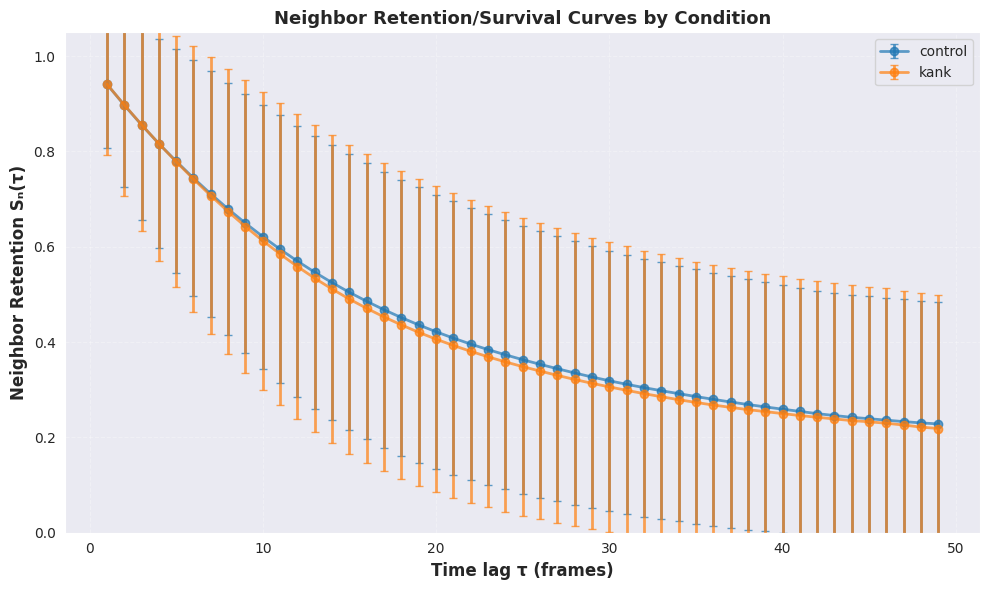

In [12]:
# Plot neighbor retention curves for all conditions
fig, ax = plt.subplots(figsize=(10, 6))

for condition in key_file["condition"].unique():
    curve_data = survival_curves[condition]
    tau = curve_data['tau']
    Sn = curve_data['Sn']
    Sn_std = curve_data['Sn_std']
    
    # Plot with error bars
    ax.errorbar(tau, Sn, yerr=Sn_std, marker='o', label=condition, linewidth=2, capsize=3, alpha=0.7)

ax.set_xlabel('Time lag τ (frames)', fontsize=12, fontweight='bold')
ax.set_ylabel('Neighbor Retention Sₙ(τ)', fontsize=12, fontweight='bold')
ax.set_title('Neighbor Retention/Survival Curves by Condition', fontsize=13, fontweight='bold')
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [13]:
# Fit exponential decay to retention curves and extract half-life
from scipy.optimize import curve_fit

def exponential_decay(tau, S0, k):
    """
    Exponential decay model: S(τ) = S0 * exp(-k*τ)
    """
    return S0 * np.exp(-k * tau)

retention_analysis = {}

for condition in key_file["condition"].unique():
    print(f"\n--- Fitting decay model for condition: {condition} ---")
    
    curve_data = survival_curves[condition]
    tau = curve_data['tau']
    Sn = curve_data['Sn']
    Sn_std = curve_data['Sn_std']
    
    # Fit exponential decay
    try:
        # Use weights inverse to variance for better fitting
        weights = 1.0 / (Sn_std + 1e-6)
        
        popt, pcov = curve_fit(
            exponential_decay, 
            tau, 
            Sn,
            p0=[1.0, 0.1],
            sigma=Sn_std,
            absolute_sigma=True,
            maxfev=5000
        )
        
        S0, k = popt
        S0_err, k_err = np.sqrt(np.diag(pcov))
        
        # Calculate half-life: t_1/2 = ln(2) / k
        if k > 0:
            half_life = np.log(2) / k
            half_life_err = (np.log(2) / (k**2)) * k_err
        else:
            half_life = np.inf
            half_life_err = np.inf
        
        retention_analysis[condition] = {
            'S0': S0,
            'S0_err': S0_err,
            'k': k,
            'k_err': k_err,
            'half_life': half_life,
            'half_life_err': half_life_err,
            'fit_success': True
        }
        
        print(f"  S0 (initial retention): {S0:.3f} ± {S0_err:.3f}")
        print(f"  Decay rate k: {k:.4f} ± {k_err:.4f} frame⁻¹")
        print(f"  Half-life t_1/2: {half_life:.2f} ± {half_life_err:.2f} frames")
        
    except Exception as e:
        print(f"  Warning: Fitting failed - {e}")
        retention_analysis[condition] = {'fit_success': False}


--- Fitting decay model for condition: control ---
  S0 (initial retention): 0.932 ± 0.085
  Decay rate k: 0.0351 ± 0.0063 frame⁻¹
  Half-life t_1/2: 19.75 ± 3.53 frames

--- Fitting decay model for condition: kank ---
  S0 (initial retention): 0.935 ± 0.096
  Decay rate k: 0.0365 ± 0.0072 frame⁻¹
  Half-life t_1/2: 18.97 ± 3.75 frames


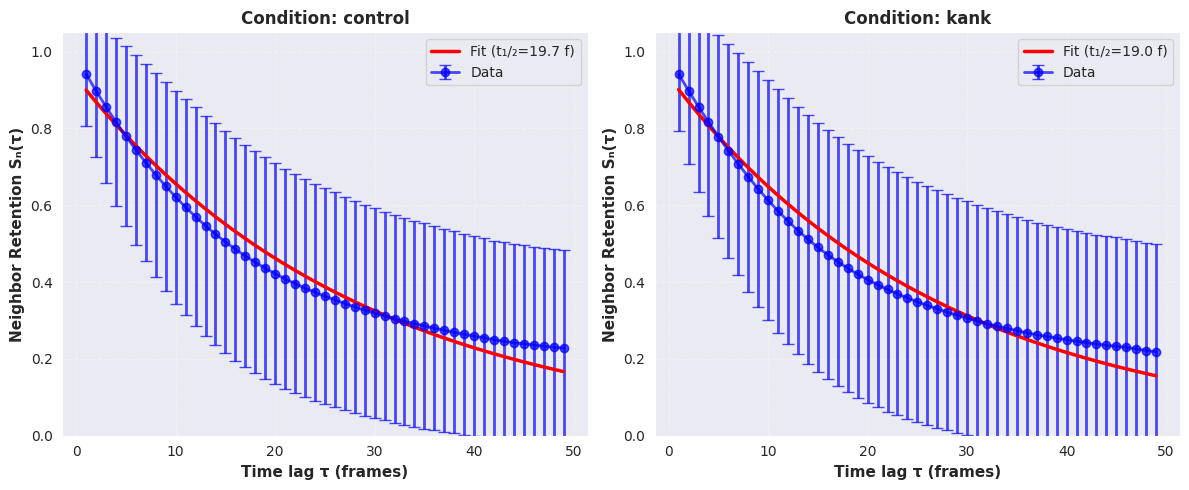

In [14]:
# Plot retention curves with exponential fits
fig, axes = plt.subplots(1, len(key_file["condition"].unique()), 
                          figsize=(6 * len(key_file["condition"].unique()), 5))

if len(key_file["condition"].unique()) == 1:
    axes = [axes]

for ax, condition in zip(axes, key_file["condition"].unique()):
    curve_data = survival_curves[condition]
    tau = curve_data['tau']
    Sn = curve_data['Sn']
    Sn_std = curve_data['Sn_std']
    
    # Plot data with error bars
    ax.errorbar(tau, Sn, yerr=Sn_std, marker='o', markersize=6, label='Data',
                linewidth=2, capsize=4, color='blue', alpha=0.7)
    
    # Plot fit if successful
    if retention_analysis[condition]['fit_success']:
        S0 = retention_analysis[condition]['S0']
        k = retention_analysis[condition]['k']
        half_life = retention_analysis[condition]['half_life']
        
        # Generate smooth fit curve
        tau_smooth = np.linspace(tau[0], tau[-1], 100)
        Sn_fit = exponential_decay(tau_smooth, S0, k)
        
        ax.plot(tau_smooth, Sn_fit, 'r-', linewidth=2.5, label=f'Fit (t₁/₂={half_life:.1f} f)')
    
    ax.set_xlabel('Time lag τ (frames)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Neighbor Retention Sₙ(τ)', fontsize=11, fontweight='bold')
    ax.set_title(f'Condition: {condition}', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1.05])
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [15]:
# Summary table of retention metrics
print("\n" + "="*70)
print("NEIGHBOR RETENTION ANALYSIS SUMMARY")
print("="*70)

summary_data = []
for condition in key_file["condition"].unique():
    # Get all experiments for this condition
    experiments_for_condition = key_file[key_file["condition"] == condition]
    n_experiments = len(experiments_for_condition)
    
    analysis = retention_analysis[condition]
    
    summary_row = {
        'Condition': condition,
        'N Experiments': n_experiments,
    }
    
    if analysis.get('fit_success'):
        summary_row['S0 (initial)'] = f"{analysis['S0']:.3f} ± {analysis['S0_err']:.3f}"
        summary_row['k (decay rate)'] = f"{analysis['k']:.4f} ± {analysis['k_err']:.4f}"
        summary_row['Half-life (frames)'] = f"{analysis['half_life']:.2f} ± {analysis['half_life_err']:.2f}"
    else:
        summary_row['S0 (initial)'] = 'N/A'
        summary_row['k (decay rate)'] = 'N/A'
        summary_row['Half-life (frames)'] = 'N/A'
    
    summary_data.append(summary_row)

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print("="*70)


NEIGHBOR RETENTION ANALYSIS SUMMARY
Condition  N Experiments  S0 (initial)  k (decay rate) Half-life (frames)
  control              3 0.932 ± 0.085 0.0351 ± 0.0063       19.75 ± 3.53
     kank              3 0.935 ± 0.096 0.0365 ± 0.0072       18.97 ± 3.75


In [16]:
# Relative neighbor separation / cage-relative displacement
# For each initial neighbor pair (i,j) at time t0, compute the change in relative displacement:
#   δr_ij(τ) = |[r_i(t0+τ) - r_j(t0+τ)] - [r_i(t0) - r_j(t0)]|
# Small δr means neighbors move as a pack (collective); large δr means they shear apart.

def compute_relative_neighbor_displacement(graphs_dict, key_file, observation_time):
    """
    Compute the cage-relative displacement curve for each condition.
    
    For each initial neighbor pair (i,j) at time t0, tracks how the relative
    separation vector changes over time lag τ compared to the initial spacing.
    
    Returns a dict mapping condition -> {'tau', 'delta_r_mean', 'delta_r_std',
    'delta_r_sem', 'N_pairs'}.
    """
    start_frame, end_frame = observation_time
    max_tau = end_frame - start_frame - 1

    displacement_curves = {}

    for condition in key_file["condition"].unique():
        print(f"\nComputing relative neighbor displacement for condition: {condition}")

        experiments_for_condition = key_file[key_file["condition"] == condition]

        # Collect δr values per τ across all experiments, t0, and pairs
        delta_r_by_tau = {tau: [] for tau in range(1, max_tau + 1)}

        for _, row in experiments_for_condition.iterrows():
            experimentID = row["experimentID"]

            if experimentID not in graphs_dict:
                print(f"  Skipping {experimentID} – no graphs")
                continue

            t_graphs = graphs_dict[experimentID]

            # Iterate over starting time indices t0
            for t0_idx in range(len(t_graphs) - 1):
                G_t0 = t_graphs[t0_idx]

                # For every edge (i, j) at t0
                for i, j in G_t0.edges():
                    # Initial positions
                    ri_t0 = np.array([G_t0.nodes[i]["x"], G_t0.nodes[i]["y"]])
                    rj_t0 = np.array([G_t0.nodes[j]["x"], G_t0.nodes[j]["y"]])
                    d_ij_t0 = ri_t0 - rj_t0  # initial relative vector

                    # Track over future lags
                    for tau in range(1, max_tau + 1):
                        t_idx = t0_idx + tau
                        if t_idx >= len(t_graphs):
                            break

                        G_t = t_graphs[t_idx]

                        # Both nodes must still exist at t0+τ
                        if i not in G_t.nodes() or j not in G_t.nodes():
                            continue

                        ri_t = np.array([G_t.nodes[i]["x"], G_t.nodes[i]["y"]])
                        rj_t = np.array([G_t.nodes[j]["x"], G_t.nodes[j]["y"]])
                        d_ij_t = ri_t - rj_t  # relative vector at t0+τ

                        # Cage-relative displacement
                        delta_r = np.linalg.norm(d_ij_t - d_ij_t0)
                        delta_r_by_tau[tau].append(delta_r)

        # Aggregate statistics per τ
        tau_values = []
        mean_values = []
        std_values = []
        sem_values = []
        n_pairs_values = []

        for tau in sorted(delta_r_by_tau.keys()):
            vals = delta_r_by_tau[tau]
            if len(vals) > 0:
                tau_values.append(tau)
                mean_values.append(np.mean(vals))
                std_values.append(np.std(vals))
                sem_values.append(np.std(vals) / np.sqrt(len(vals)))
                n_pairs_values.append(len(vals))

        displacement_curves[condition] = {
            "tau": np.array(tau_values),
            "delta_r_mean": np.array(mean_values),
            "delta_r_std": np.array(std_values),
            "delta_r_sem": np.array(sem_values),
            "N_pairs": np.array(n_pairs_values),
        }

        print(f"  {len(tau_values)} τ-points, "
              f"avg {np.mean(n_pairs_values):.0f} pairs per τ" if len(n_pairs_values) else "")

    return displacement_curves


displacement_curves = compute_relative_neighbor_displacement(graphs, key_file, observation_time)


Computing relative neighbor displacement for condition: control
  49 τ-points, avg 489551 pairs per τ

Computing relative neighbor displacement for condition: kank
  49 τ-points, avg 324824 pairs per τ


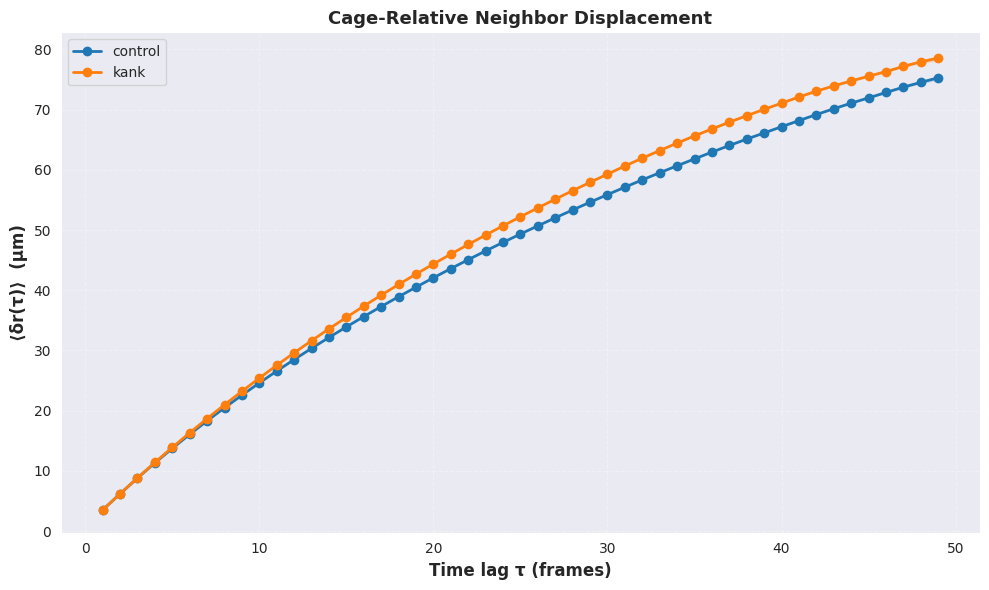

In [17]:
# Plot cage-relative displacement ⟨δr(τ)⟩ for all conditions
fig, ax = plt.subplots(figsize=(10, 6))

for condition in key_file["condition"].unique():
    cd = displacement_curves[condition]
    tau = cd["tau"]
    mean = cd["delta_r_mean"]
    sem = cd["delta_r_sem"]

    ax.plot(tau, mean, marker="o", linewidth=2, label=condition)
    ax.fill_between(tau, mean - sem, mean + sem, alpha=0.2)

ax.set_xlabel("Time lag τ (frames)", fontsize=12, fontweight="bold")
ax.set_ylabel("⟨δr(τ)⟩  (µm)", fontsize=12, fontweight="bold")
ax.set_title("Cage-Relative Neighbor Displacement", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

neighborhood consistency as a heatmap (tracks × time) to identify locally unstable areas

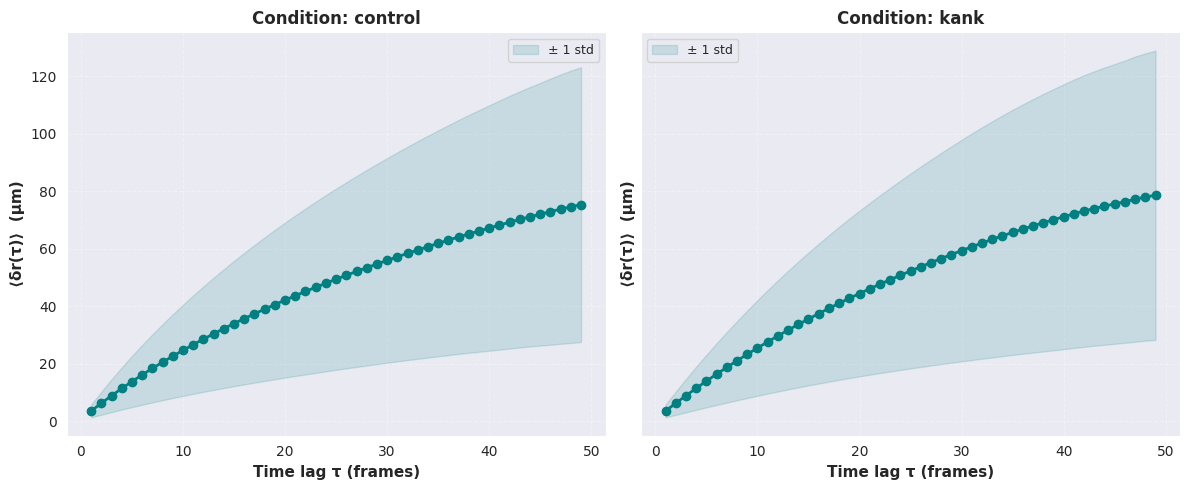

In [18]:

# Per-condition subplots: mean ± std (shaded) with pair counts annotated
conditions = key_file["condition"].unique()
n_cond = len(conditions)

fig, axes = plt.subplots(1, n_cond, figsize=(6 * n_cond, 5), sharey=True)
if n_cond == 1:
    axes = [axes]

for ax, condition in zip(axes, conditions):
    cd = displacement_curves[condition]
    tau = cd["tau"]
    mean = cd["delta_r_mean"]
    std = cd["delta_r_std"]

    ax.plot(tau, mean, "o-", color="teal", linewidth=2)
    ax.fill_between(tau, mean - std, mean + std, color="teal", alpha=0.15, label="± 1 std")
    ax.set_xlabel("Time lag τ (frames)", fontsize=11, fontweight="bold")
    ax.set_ylabel("⟨δr(τ)⟩  (µm)", fontsize=11, fontweight="bold")
    ax.set_title(f"Condition: {condition}", fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [19]:

# Summary table of cage-relative displacement metrics
print("\n" + "=" * 80)
print("CAGE-RELATIVE NEIGHBOR DISPLACEMENT SUMMARY")
print("=" * 80)

summary_rows = []
for condition in key_file["condition"].unique():
    cd = displacement_curves[condition]
    if len(cd["tau"]) == 0:
        continue

    # δr at τ=1 and at the last available τ
    dr_first = cd["delta_r_mean"][0]
    dr_last = cd["delta_r_mean"][-1]
    tau_last = cd["tau"][-1]

    # Slope of linear fit (simple metric for rate of separation)
    if len(cd["tau"]) > 1:
        coeffs = np.polyfit(cd["tau"], cd["delta_r_mean"], 1)
        slope = coeffs[0]
    else:
        slope = np.nan

    summary_rows.append({
        "Condition": condition,
        "⟨δr⟩ at τ=1 (µm)": f"{dr_first:.2f}",
        f"⟨δr⟩ at τ={tau_last} (µm)": f"{dr_last:.2f}",
        "Linear slope (µm/frame)": f"{slope:.3f}",
        "Avg pairs per τ": f"{np.mean(cd['N_pairs']):.0f}",
    })

summary_disp_df = pd.DataFrame(summary_rows)
print(summary_disp_df.to_string(index=False))
print("=" * 80)


CAGE-RELATIVE NEIGHBOR DISPLACEMENT SUMMARY
Condition ⟨δr⟩ at τ=1 (µm) ⟨δr⟩ at τ=49 (µm) Linear slope (µm/frame) Avg pairs per τ
  control             3.52             75.29                   1.448          489551
     kank             3.52             78.54                   1.538          324824


In [20]:
def _node_velocity(graphs_list, node_id, t_idx):
    """Return velocity vector of *node_id* at frame index *t_idx*.

    Velocity is the displacement to the next frame:  v(t) = r(t+1) − r(t).
    Returns None if the node is missing at t or t+1.
    """
    if t_idx + 1 >= len(graphs_list):
        return None
    G0 = graphs_list[t_idx]
    G1 = graphs_list[t_idx + 1]
    if node_id not in G0.nodes() or node_id not in G1.nodes():
        return None
    r0 = np.array([G0.nodes[node_id]["x"], G0.nodes[node_id]["y"]])
    r1 = np.array([G1.nodes[node_id]["x"], G1.nodes[node_id]["y"]])
    return r1 - r0


def _unit(v):
    """Return the unit vector.  Returns None for zero-length vectors."""
    n = np.linalg.norm(v)
    if n < 1e-12:
        return None
    return v / n


def compute_velocity_alignment_curves(graphs_dict, key_file, observation_time,
                                       use_unnormalized=False):
    """Compute neighbor velocity alignment C_align(τ) for each condition.

    Parameters
    ----------
    graphs_dict : dict
        experimentID -> list of nx.Graph (one per frame).
    key_file : pd.DataFrame
        Must contain 'experimentID' and 'condition' columns.
    observation_time : tuple (start_frame, end_frame)
    use_unnormalized : bool
        If True, use raw velocity dot-products (speed matters).
        If False (default), use unit-vector dot-products (pure alignment).

    Returns
    -------
    alignment_curves : dict
        condition -> {'tau', 'C_mean', 'C_std', 'C_sem', 'N_pairs'}
    """
    start_frame, end_frame = observation_time
    max_tau = end_frame - start_frame - 2  # need one extra frame to compute v

    alignment_curves = {}

    for condition in key_file["condition"].unique():
        print(f"\nComputing velocity alignment for condition: {condition}")

        experiments = key_file[key_file["condition"] == condition]

        dot_by_tau = {tau: [] for tau in range(0, max_tau + 1)}  # τ=0 included

        for _, row in experiments.iterrows():
            experimentID = row["experimentID"]
            if experimentID not in graphs_dict:
                print(f"  Skipping {experimentID} – no graphs")
                continue

            t_graphs = graphs_dict[experimentID]

            # Pre-compute velocities for all nodes at all valid time indices
            # t_idx ranges over [0 .. len-2] (need t+1 for displacement)
            vel_cache = {}  # (node_id, t_idx) -> velocity vector | None
            for t_idx in range(len(t_graphs) - 1):
                G = t_graphs[t_idx]
                for nid in G.nodes():
                    vel_cache[(nid, t_idx)] = _node_velocity(t_graphs, nid, t_idx)

            # Iterate over starting time indices t0
            for t0_idx in range(len(t_graphs) - 1):
                G_t0 = t_graphs[t0_idx]

                for i, j in G_t0.edges():
                    vi = vel_cache.get((i, t0_idx))
                    if vi is None:
                        continue

                    if not use_unnormalized:
                        vi_use = _unit(vi)
                        if vi_use is None:
                            continue
                    else:
                        vi_use = vi

                    # For each lag τ (including τ=0 = same-time alignment)
                    for tau in range(0, max_tau + 1):
                        tj_idx = t0_idx + tau
                        if tj_idx >= len(t_graphs) - 1:
                            break

                        vj = vel_cache.get((j, tj_idx))
                        if vj is None:
                            continue

                        if not use_unnormalized:
                            vj_use = _unit(vj)
                            if vj_use is None:
                                continue
                        else:
                            vj_use = vj

                        dot_by_tau[tau].append(np.dot(vi_use, vj_use))

        # Aggregate
        tau_vals, mean_vals, std_vals, sem_vals, n_vals = [], [], [], [], []
        for tau in sorted(dot_by_tau.keys()):
            vals = dot_by_tau[tau]
            if len(vals) > 0:
                tau_vals.append(tau)
                mean_vals.append(np.mean(vals))
                std_vals.append(np.std(vals))
                sem_vals.append(np.std(vals) / np.sqrt(len(vals)))
                n_vals.append(len(vals))

        alignment_curves[condition] = {
            "tau": np.array(tau_vals),
            "C_mean": np.array(mean_vals),
            "C_std": np.array(std_vals),
            "C_sem": np.array(sem_vals),
            "N_pairs": np.array(n_vals),
        }

        print(f"  {len(tau_vals)} τ-points, "
              f"avg {np.mean(n_vals):.0f} pairs per τ" if n_vals else "")

    return alignment_curves


# Compute alignment curves (normalized – pure directional alignment)
alignment_curves_norm = compute_velocity_alignment_curves(
    graphs, key_file, observation_time, use_unnormalized=False
)

# Compute alignment curves (unnormalized – speed-weighted)
alignment_curves_unnorm = compute_velocity_alignment_curves(
    graphs, key_file, observation_time, use_unnormalized=True
)



Computing velocity alignment for condition: control
  49 τ-points, avg 461296 pairs per τ

Computing velocity alignment for condition: kank
  49 τ-points, avg 306541 pairs per τ

Computing velocity alignment for condition: control
  49 τ-points, avg 501889 pairs per τ

Computing velocity alignment for condition: kank
  49 τ-points, avg 333097 pairs per τ


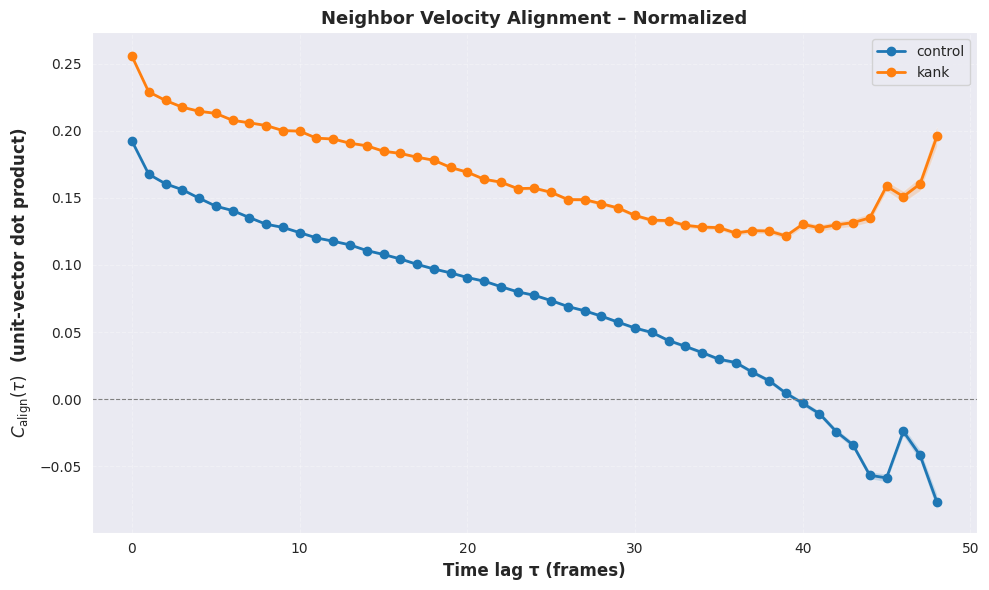

In [21]:

# Plot normalized velocity alignment  C_align(τ)  for all conditions
fig, ax = plt.subplots(figsize=(10, 6))

for condition in key_file["condition"].unique():
    cd = alignment_curves_norm[condition]
    tau = cd["tau"]
    mean = cd["C_mean"]
    sem = cd["C_sem"]

    ax.plot(tau, mean, marker="o", linewidth=2, label=condition)
    ax.fill_between(tau, mean - sem, mean + sem, alpha=0.2)

ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("Time lag τ (frames)", fontsize=12, fontweight="bold")
ax.set_ylabel(r"$C_{\mathrm{align}}(\tau)$  (unit-vector dot product)", fontsize=12, fontweight="bold")
ax.set_title("Neighbor Velocity Alignment – Normalized", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()



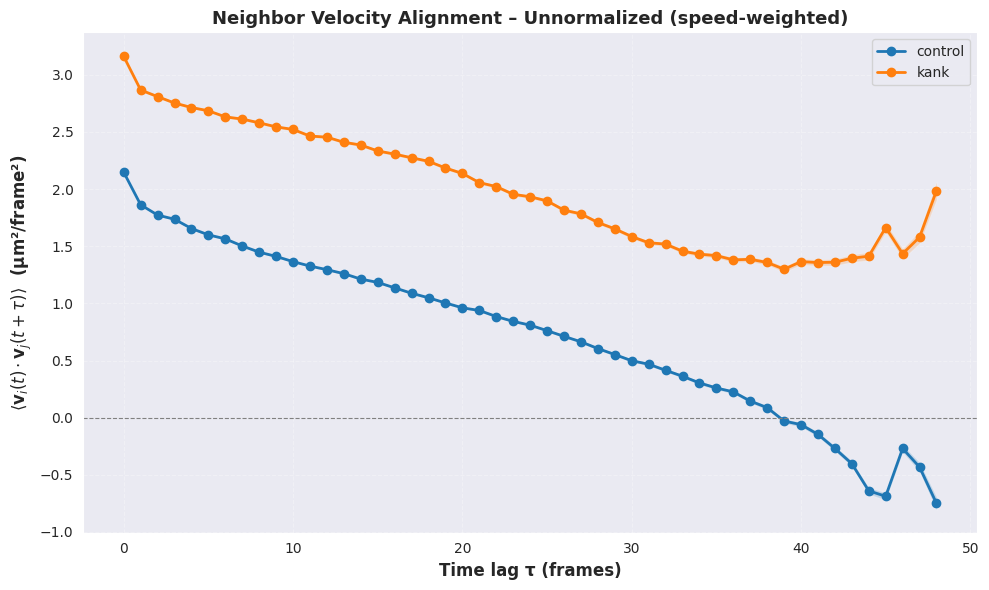

In [22]:

# Plot unnormalized (speed-weighted) velocity alignment for all conditions
fig, ax = plt.subplots(figsize=(10, 6))

for condition in key_file["condition"].unique():
    cd = alignment_curves_unnorm[condition]
    tau = cd["tau"]
    mean = cd["C_mean"]
    sem = cd["C_sem"]

    ax.plot(tau, mean, marker="o", linewidth=2, label=condition)
    ax.fill_between(tau, mean - sem, mean + sem, alpha=0.2)

ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("Time lag τ (frames)", fontsize=12, fontweight="bold")
ax.set_ylabel(r"$\langle \mathbf{v}_i(t) \cdot \mathbf{v}_j(t+\tau) \rangle$  (µm²/frame²)",
              fontsize=12, fontweight="bold")
ax.set_title("Neighbor Velocity Alignment – Unnormalized (speed-weighted)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

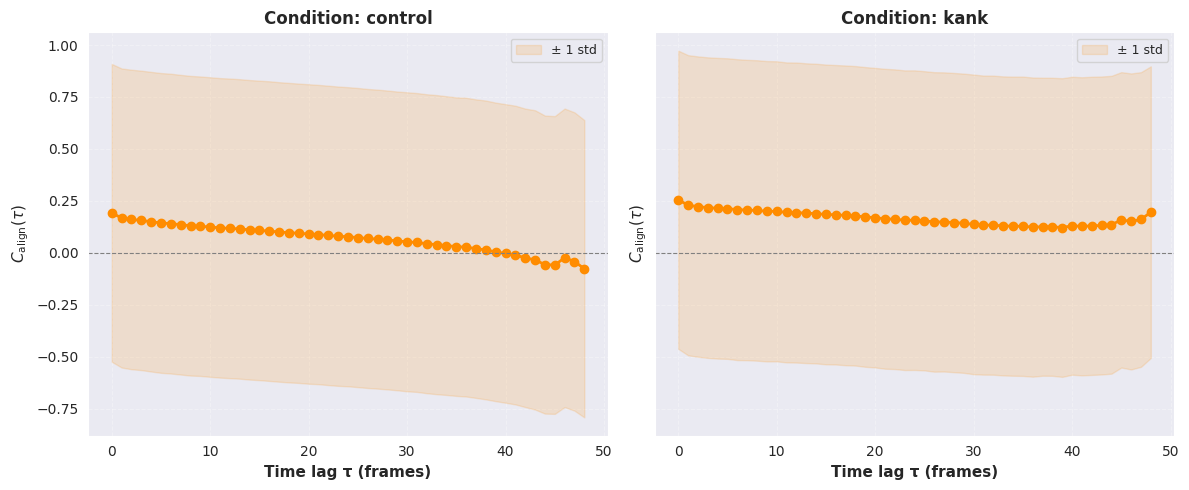

In [23]:

# Per-condition subplots: normalized alignment  ±  1 std
conditions = key_file["condition"].unique()
n_cond = len(conditions)

fig, axes = plt.subplots(1, n_cond, figsize=(6 * n_cond, 5), sharey=True)
if n_cond == 1:
    axes = [axes]

for ax, condition in zip(axes, conditions):
    cd = alignment_curves_norm[condition]
    tau = cd["tau"]
    mean = cd["C_mean"]
    std = cd["C_std"]

    ax.plot(tau, mean, "o-", color="darkorange", linewidth=2)
    ax.fill_between(tau, mean - std, mean + std, color="darkorange", alpha=0.15, label="± 1 std")
    ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Time lag τ (frames)", fontsize=11, fontweight="bold")
    ax.set_ylabel(r"$C_{\mathrm{align}}(\tau)$", fontsize=11, fontweight="bold")
    ax.set_title(f"Condition: {condition}", fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [24]:

# Fit exponential decay to alignment curves and extract decorrelation time
from scipy.optimize import curve_fit

def alignment_decay(tau, C0, k):
    """Exponential decay: C(τ) = C0 * exp(-k * τ)"""
    return C0 * np.exp(-k * tau)

alignment_fit_results = {}

for condition in key_file["condition"].unique():
    print(f"\n--- Fitting alignment decay for condition: {condition} ---")

    cd = alignment_curves_norm[condition]
    tau = cd["tau"]
    C = cd["C_mean"]
    C_std = cd["C_std"]

    # Use only τ >= 0 where C > 0 for exponential fit
    mask = C > 0
    if mask.sum() < 3:
        print("  Not enough positive points for fitting.")
        alignment_fit_results[condition] = {"fit_success": False}
        continue

    try:
        popt, pcov = curve_fit(
            alignment_decay,
            tau[mask], C[mask],
            p0=[C[0], 0.1],
            sigma=C_std[mask] + 1e-8,
            absolute_sigma=True,
            maxfev=5000,
        )
        C0, k = popt
        C0_err, k_err = np.sqrt(np.diag(pcov))

        # Decorrelation time (1/e time): τ_d = 1/k
        if k > 0:
            tau_d = 1.0 / k
            tau_d_err = k_err / (k ** 2)
        else:
            tau_d = np.inf
            tau_d_err = np.inf

        alignment_fit_results[condition] = {
            "C0": C0, "C0_err": C0_err,
            "k": k, "k_err": k_err,
            "tau_d": tau_d, "tau_d_err": tau_d_err,
            "fit_success": True,
        }

        print(f"  C0 (initial alignment): {C0:.4f} ± {C0_err:.4f}")
        print(f"  Decay rate k: {k:.4f} ± {k_err:.4f} frame⁻¹")
        print(f"  Decorrelation time τ_d = 1/k: {tau_d:.2f} ± {tau_d_err:.2f} frames")

    except Exception as e:
        print(f"  Fitting failed – {e}")
        alignment_fit_results[condition] = {"fit_success": False}


--- Fitting alignment decay for condition: control ---
  C0 (initial alignment): 0.1849 ± 0.3081
  Decay rate k: 0.0414 ± 0.1227 frame⁻¹
  Decorrelation time τ_d = 1/k: 24.15 ± 71.57 frames

--- Fitting alignment decay for condition: kank ---
  C0 (initial alignment): 0.2242 ± 0.2333
  Decay rate k: 0.0130 ± 0.0444 frame⁻¹
  Decorrelation time τ_d = 1/k: 77.17 ± 264.62 frames


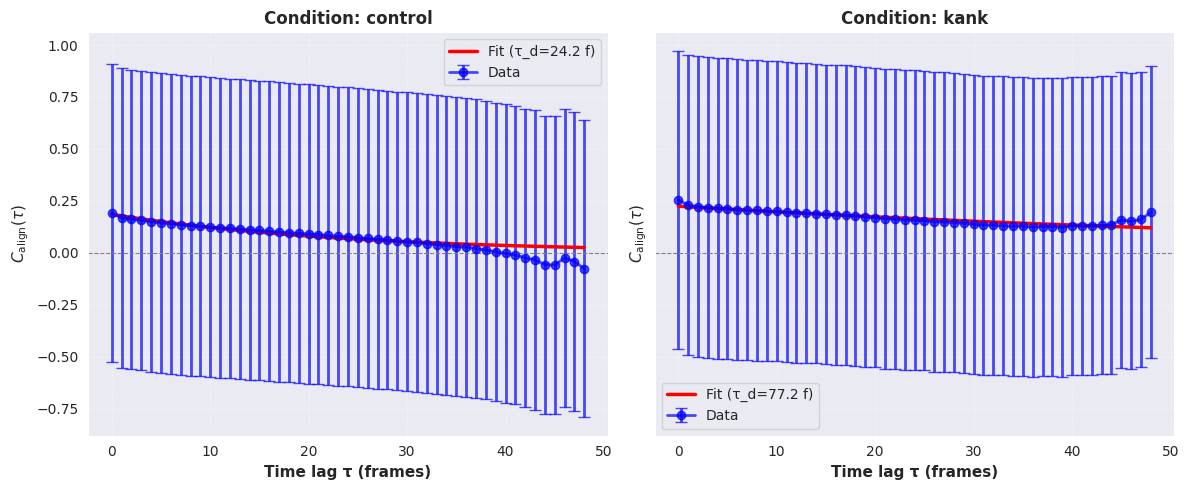

In [25]:


# Plot alignment curves with exponential fits overlaid
conditions = key_file["condition"].unique()
n_cond = len(conditions)

fig, axes = plt.subplots(1, n_cond, figsize=(6 * n_cond, 5), sharey=True)
if n_cond == 1:
    axes = [axes]

for ax, condition in zip(axes, conditions):
    cd = alignment_curves_norm[condition]
    tau = cd["tau"]
    C = cd["C_mean"]
    C_std = cd["C_std"]

    ax.errorbar(tau, C, yerr=C_std, marker="o", markersize=6, label="Data",
                linewidth=2, capsize=4, color="blue", alpha=0.7)

    res = alignment_fit_results[condition]
    if res.get("fit_success"):
        tau_smooth = np.linspace(tau[0], tau[-1], 200)
        C_fit = alignment_decay(tau_smooth, res["C0"], res["k"])
        ax.plot(tau_smooth, C_fit, "r-", linewidth=2.5,
                label=f"Fit (τ_d={res['tau_d']:.1f} f)")

    ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Time lag τ (frames)", fontsize=11, fontweight="bold")
    ax.set_ylabel(r"$C_{\mathrm{align}}(\tau)$", fontsize=11, fontweight="bold")
    ax.set_title(f"Condition: {condition}", fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


In [26]:

# Summary table of velocity alignment metrics
print("\n" + "=" * 80)
print("NEIGHBOR VELOCITY ALIGNMENT SUMMARY")
print("=" * 80)

summary_rows_align = []
for condition in key_file["condition"].unique():
    cd_norm = alignment_curves_norm[condition]
    cd_unnorm = alignment_curves_unnorm[condition]

    row_data = {"Condition": condition}

    # Same-time alignment A(τ=0)
    if len(cd_norm["tau"]) > 0 and cd_norm["tau"][0] == 0:
        row_data["A(τ=0) norm"] = f"{cd_norm['C_mean'][0]:.4f} ± {cd_norm['C_std'][0]:.4f}"
    else:
        row_data["A(τ=0) norm"] = "N/A"

    if len(cd_unnorm["tau"]) > 0 and cd_unnorm["tau"][0] == 0:
        row_data["A(τ=0) unnorm (µm²/f²)"] = (
            f"{cd_unnorm['C_mean'][0]:.2f} ± {cd_unnorm['C_std'][0]:.2f}"
        )
    else:
        row_data["A(τ=0) unnorm (µm²/f²)"] = "N/A"

    # Decorrelation time from fit
    res = alignment_fit_results[condition]
    if res.get("fit_success"):
        row_data["τ_d (frames)"] = f"{res['tau_d']:.2f} ± {res['tau_d_err']:.2f}"
        row_data["C0"] = f"{res['C0']:.4f} ± {res['C0_err']:.4f}"
    else:
        row_data["τ_d (frames)"] = "N/A"
        row_data["C0"] = "N/A"

    row_data["Avg pairs per τ"] = f"{np.mean(cd_norm['N_pairs']):.0f}"

    summary_rows_align.append(row_data)

summary_align_df = pd.DataFrame(summary_rows_align)
print(summary_align_df.to_string(index=False))
print("=" * 80)


NEIGHBOR VELOCITY ALIGNMENT SUMMARY
Condition     A(τ=0) norm A(τ=0) unnorm (µm²/f²)   τ_d (frames)              C0 Avg pairs per τ
  control 0.1923 ± 0.7166            2.15 ± 9.02  24.15 ± 71.57 0.1849 ± 0.3081          461296
     kank 0.2554 ± 0.7174           3.16 ± 10.00 77.17 ± 264.62 0.2242 ± 0.2333          306541


In [27]:
def compute_anisotropic_separation_and_msd(graphs_dict, key_file, observation_time):
    """
    Compute flow-decomposed pairwise separation and single-cell MSD.

    Parameters
    ----------
    graphs_dict : dict
        experimentID -> list of nx.Graph (one per frame).
    key_file : pd.DataFrame
        Must contain 'experimentID' and 'condition' columns.
    observation_time : tuple (start_frame, end_frame)

    Returns
    -------
    pair_sep : dict
        condition -> {'tau', 'dx2_mean', 'dx2_std', 'dx2_sem',
                       'dy2_mean', 'dy2_std', 'dy2_sem', 'N_pairs'}
    msd_aniso : dict
        condition -> {'tau', 'msd_par_mean', 'msd_par_std', 'msd_par_sem',
                       'msd_perp_mean', 'msd_perp_std', 'msd_perp_sem', 'N_cells'}
    """
    start_frame, end_frame = observation_time
    max_tau = end_frame - start_frame - 1

    pair_sep = {}
    msd_aniso = {}

    for condition in key_file["condition"].unique():
        print(f"\nComputing anisotropic metrics for condition: {condition}")

        experiments = key_file[key_file["condition"] == condition]

        # Accumulators  ------------------------------------------------
        # Pair separation change squared, per τ
        dx2_by_tau = {tau: [] for tau in range(1, max_tau + 1)}
        dy2_by_tau = {tau: [] for tau in range(1, max_tau + 1)}

        # Single-cell MSD components, per τ
        msd_par_by_tau = {tau: [] for tau in range(1, max_tau + 1)}
        msd_perp_by_tau = {tau: [] for tau in range(1, max_tau + 1)}

        for _, row in experiments.iterrows():
            experimentID = row["experimentID"]
            if experimentID not in graphs_dict:
                print(f"  Skipping {experimentID} – no graphs")
                continue

            t_graphs = graphs_dict[experimentID]

            # --- Pair separation components ---
            for t0_idx in range(len(t_graphs) - 1):
                G_t0 = t_graphs[t0_idx]

                for i, j in G_t0.edges():
                    xi_t0 = G_t0.nodes[i]["x"]
                    yi_t0 = G_t0.nodes[i]["y"]
                    xj_t0 = G_t0.nodes[j]["x"]
                    yj_t0 = G_t0.nodes[j]["y"]

                    sep_x_t0 = xi_t0 - xj_t0
                    sep_y_t0 = yi_t0 - yj_t0

                    for tau in range(1, max_tau + 1):
                        t_idx = t0_idx + tau
                        if t_idx >= len(t_graphs):
                            break
                        G_t = t_graphs[t_idx]

                        if i not in G_t.nodes() or j not in G_t.nodes():
                            continue

                        xi_t = G_t.nodes[i]["x"]
                        yi_t = G_t.nodes[i]["y"]
                        xj_t = G_t.nodes[j]["x"]
                        yj_t = G_t.nodes[j]["y"]

                        dx = (xi_t - xj_t) - sep_x_t0
                        dy = (yi_t - yj_t) - sep_y_t0

                        dx2_by_tau[tau].append(dx ** 2)
                        dy2_by_tau[tau].append(dy ** 2)

            # --- Self-MSD components ---
            for t0_idx in range(len(t_graphs)):
                G_t0 = t_graphs[t0_idx]

                for nid in G_t0.nodes():
                    x0 = G_t0.nodes[nid]["x"]
                    y0 = G_t0.nodes[nid]["y"]

                    for tau in range(1, max_tau + 1):
                        t_idx = t0_idx + tau
                        if t_idx >= len(t_graphs):
                            break
                        G_t = t_graphs[t_idx]

                        if nid not in G_t.nodes():
                            continue

                        dx_self = G_t.nodes[nid]["x"] - x0
                        dy_self = G_t.nodes[nid]["y"] - y0

                        msd_par_by_tau[tau].append(dx_self ** 2)
                        msd_perp_by_tau[tau].append(dy_self ** 2)

        # --- Aggregate pair separation ---
        tau_vals_p, dx2_m, dx2_s, dx2_se, dy2_m, dy2_s, dy2_se, n_pairs = (
            [], [], [], [], [], [], [], []
        )
        for tau in sorted(dx2_by_tau.keys()):
            vx = dx2_by_tau[tau]
            vy = dy2_by_tau[tau]
            if len(vx) > 0:
                tau_vals_p.append(tau)
                dx2_m.append(np.mean(vx))
                dx2_s.append(np.std(vx))
                dx2_se.append(np.std(vx) / np.sqrt(len(vx)))
                dy2_m.append(np.mean(vy))
                dy2_s.append(np.std(vy))
                dy2_se.append(np.std(vy) / np.sqrt(len(vy)))
                n_pairs.append(len(vx))

        pair_sep[condition] = {
            "tau": np.array(tau_vals_p),
            "dx2_mean": np.array(dx2_m),
            "dx2_std": np.array(dx2_s),
            "dx2_sem": np.array(dx2_se),
            "dy2_mean": np.array(dy2_m),
            "dy2_std": np.array(dy2_s),
            "dy2_sem": np.array(dy2_se),
            "N_pairs": np.array(n_pairs),
        }

        # --- Aggregate self-MSD ---
        tau_vals_m, mp_m, mp_s, mp_se, mr_m, mr_s, mr_se, n_cells = (
            [], [], [], [], [], [], [], []
        )
        for tau in sorted(msd_par_by_tau.keys()):
            vp = msd_par_by_tau[tau]
            vr = msd_perp_by_tau[tau]
            if len(vp) > 0:
                tau_vals_m.append(tau)
                mp_m.append(np.mean(vp))
                mp_s.append(np.std(vp))
                mp_se.append(np.std(vp) / np.sqrt(len(vp)))
                mr_m.append(np.mean(vr))
                mr_s.append(np.std(vr))
                mr_se.append(np.std(vr) / np.sqrt(len(vr)))
                n_cells.append(len(vp))

        msd_aniso[condition] = {
            "tau": np.array(tau_vals_m),
            "msd_par_mean": np.array(mp_m),
            "msd_par_std": np.array(mp_s),
            "msd_par_sem": np.array(mp_se),
            "msd_perp_mean": np.array(mr_m),
            "msd_perp_std": np.array(mr_s),
            "msd_perp_sem": np.array(mr_se),
            "N_cells": np.array(n_cells),
        }

        print(f"  Pair sep: {len(tau_vals_p)} τ-points, "
              f"avg {np.mean(n_pairs):.0f} pairs/τ" if n_pairs else "")
        print(f"  Self-MSD: {len(tau_vals_m)} τ-points, "
              f"avg {np.mean(n_cells):.0f} cells/τ" if n_cells else "")

    return pair_sep, msd_aniso


pair_sep_curves, msd_aniso_curves = compute_anisotropic_separation_and_msd(
    graphs, key_file, observation_time
)



Computing anisotropic metrics for condition: control
  Pair sep: 49 τ-points, avg 489551 pairs/τ
  Self-MSD: 49 τ-points, avg 290402 cells/τ

Computing anisotropic metrics for condition: kank
  Pair sep: 49 τ-points, avg 324824 pairs/τ
  Self-MSD: 49 τ-points, avg 238059 cells/τ


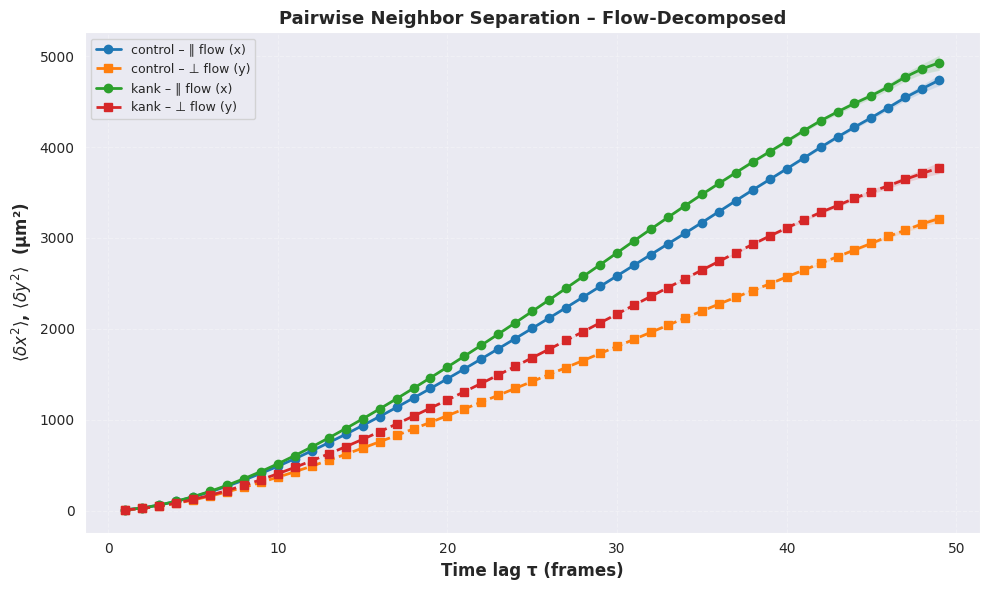

In [28]:

# ---- Plot 1: Pairwise separation ⟨δx²⟩ and ⟨δy²⟩ overlay ----
fig, ax = plt.subplots(figsize=(10, 6))

for condition in key_file["condition"].unique():
    cd = pair_sep_curves[condition]
    tau = cd["tau"]

    ax.plot(tau, cd["dx2_mean"], marker="o", linewidth=2,
            label=f"{condition} – ∥ flow (x)")
    ax.fill_between(tau, cd["dx2_mean"] - cd["dx2_sem"],
                     cd["dx2_mean"] + cd["dx2_sem"], alpha=0.15)

    ax.plot(tau, cd["dy2_mean"], marker="s", linewidth=2, linestyle="--",
            label=f"{condition} – ⊥ flow (y)")
    ax.fill_between(tau, cd["dy2_mean"] - cd["dy2_sem"],
                     cd["dy2_mean"] + cd["dy2_sem"], alpha=0.15)

ax.set_xlabel("Time lag τ (frames)", fontsize=12, fontweight="bold")
ax.set_ylabel(r"$\langle \delta x^2 \rangle$, $\langle \delta y^2 \rangle$  (µm²)",
              fontsize=12, fontweight="bold")
ax.set_title("Pairwise Neighbor Separation – Flow-Decomposed", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()


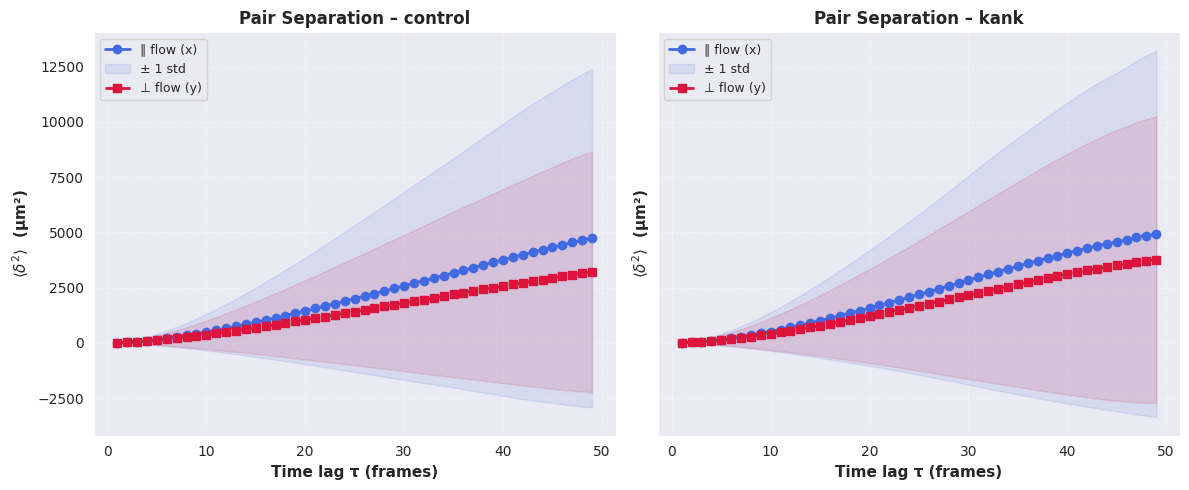

In [29]:

# ---- Plot 2: Per-condition subplots of pairwise separation ----
conditions = key_file["condition"].unique()
n_cond = len(conditions)

fig, axes = plt.subplots(1, n_cond, figsize=(6 * n_cond, 5), sharey=True)
if n_cond == 1:
    axes = [axes]

for ax, condition in zip(axes, conditions):
    cd = pair_sep_curves[condition]
    tau = cd["tau"]

    ax.plot(tau, cd["dx2_mean"], "o-", color="royalblue", linewidth=2, label="∥ flow (x)")
    ax.fill_between(tau, cd["dx2_mean"] - cd["dx2_std"],
                     cd["dx2_mean"] + cd["dx2_std"], color="royalblue", alpha=0.12, label="± 1 std")

    ax.plot(tau, cd["dy2_mean"], "s--", color="crimson", linewidth=2, label="⊥ flow (y)")
    ax.fill_between(tau, cd["dy2_mean"] - cd["dy2_std"],
                     cd["dy2_mean"] + cd["dy2_std"], color="crimson", alpha=0.12)

    ax.set_xlabel("Time lag τ (frames)", fontsize=11, fontweight="bold")
    ax.set_ylabel(r"$\langle \delta^2 \rangle$  (µm²)", fontsize=11, fontweight="bold")
    ax.set_title(f"Pair Separation – {condition}", fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


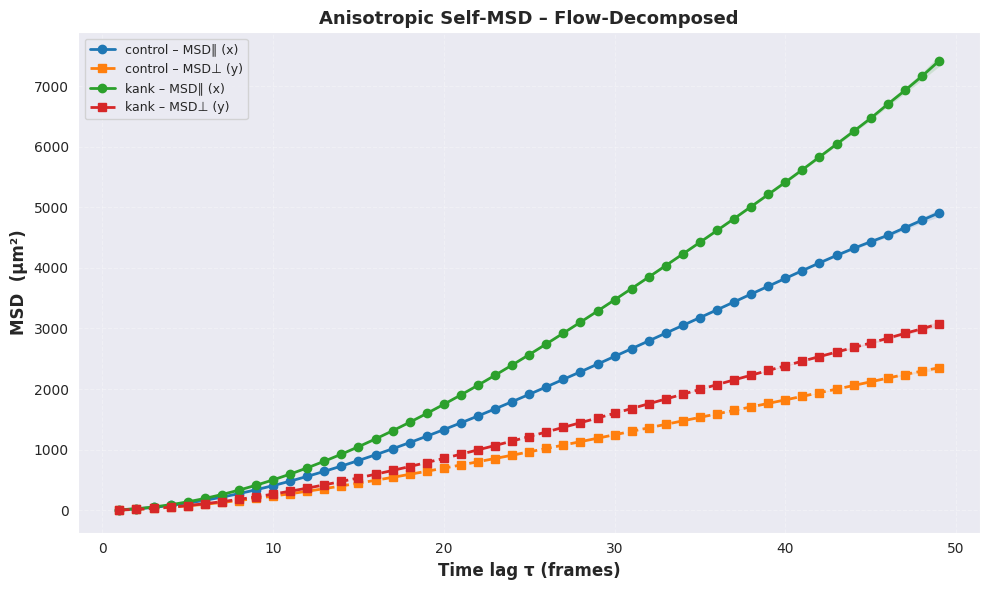

In [30]:

# ---- Plot 3: Anisotropic self-MSD overlay ----
fig, ax = plt.subplots(figsize=(10, 6))

for condition in key_file["condition"].unique():
    cd = msd_aniso_curves[condition]
    tau = cd["tau"]

    ax.plot(tau, cd["msd_par_mean"], marker="o", linewidth=2,
            label=f"{condition} – MSD∥ (x)")
    ax.fill_between(tau, cd["msd_par_mean"] - cd["msd_par_sem"],
                     cd["msd_par_mean"] + cd["msd_par_sem"], alpha=0.15)

    ax.plot(tau, cd["msd_perp_mean"], marker="s", linewidth=2, linestyle="--",
            label=f"{condition} – MSD⊥ (y)")
    ax.fill_between(tau, cd["msd_perp_mean"] - cd["msd_perp_sem"],
                     cd["msd_perp_mean"] + cd["msd_perp_sem"], alpha=0.15)

ax.set_xlabel("Time lag τ (frames)", fontsize=12, fontweight="bold")
ax.set_ylabel(r"MSD  (µm²)", fontsize=12, fontweight="bold")
ax.set_title("Anisotropic Self-MSD – Flow-Decomposed", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

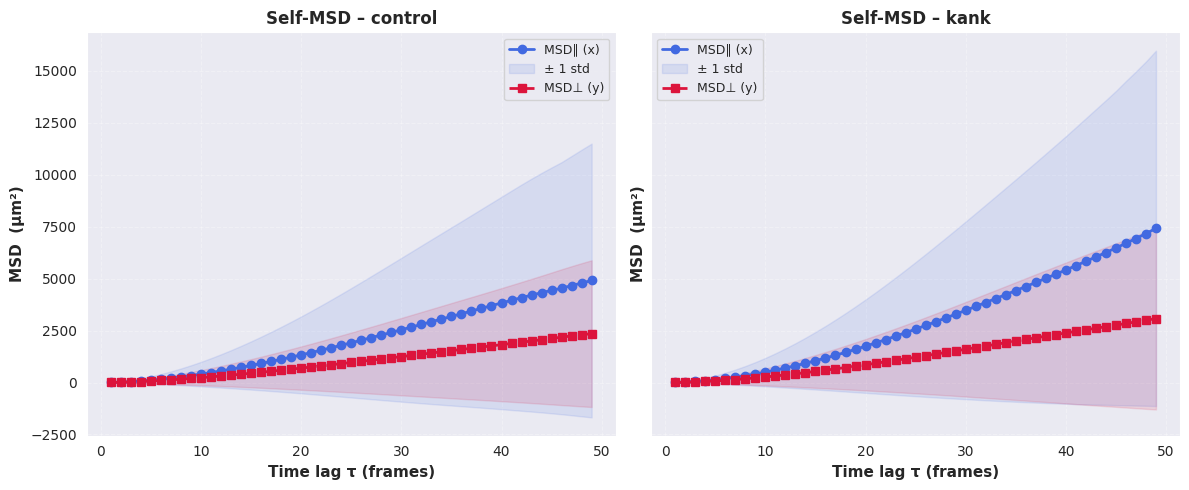

In [31]:

# ---- Plot 4: Per-condition subplots of anisotropic self-MSD ----
conditions = key_file["condition"].unique()
n_cond = len(conditions)

fig, axes = plt.subplots(1, n_cond, figsize=(6 * n_cond, 5), sharey=True)
if n_cond == 1:
    axes = [axes]

for ax, condition in zip(axes, conditions):
    cd = msd_aniso_curves[condition]
    tau = cd["tau"]

    ax.plot(tau, cd["msd_par_mean"], "o-", color="royalblue", linewidth=2, label="MSD∥ (x)")
    ax.fill_between(tau, cd["msd_par_mean"] - cd["msd_par_std"],
                     cd["msd_par_mean"] + cd["msd_par_std"], color="royalblue", alpha=0.12,
                     label="± 1 std")

    ax.plot(tau, cd["msd_perp_mean"], "s--", color="crimson", linewidth=2, label="MSD⊥ (y)")
    ax.fill_between(tau, cd["msd_perp_mean"] - cd["msd_perp_std"],
                     cd["msd_perp_mean"] + cd["msd_perp_std"], color="crimson", alpha=0.12)

    ax.set_xlabel("Time lag τ (frames)", fontsize=11, fontweight="bold")
    ax.set_ylabel("MSD  (µm²)", fontsize=11, fontweight="bold")
    ax.set_title(f"Self-MSD – {condition}", fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


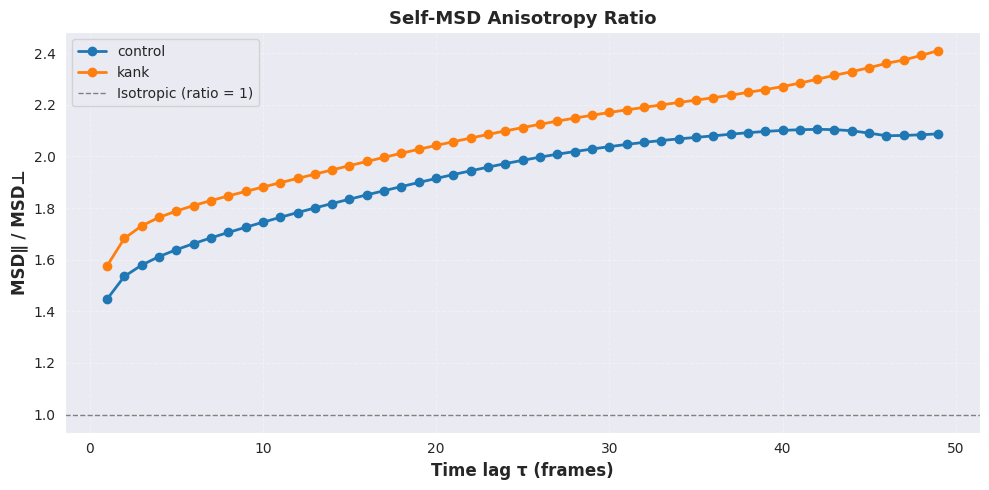

In [32]:


# ---- Plot 5: Anisotropy ratio MSD∥ / MSD⊥ ----
fig, ax = plt.subplots(figsize=(10, 5))

for condition in key_file["condition"].unique():
    cd = msd_aniso_curves[condition]
    tau = cd["tau"]

    # Avoid division by zero
    ratio = np.where(cd["msd_perp_mean"] > 1e-12,
                     cd["msd_par_mean"] / cd["msd_perp_mean"],
                     np.nan)

    ax.plot(tau, ratio, marker="o", linewidth=2, label=condition)

ax.axhline(1, color="grey", linewidth=1, linestyle="--", label="Isotropic (ratio = 1)")
ax.set_xlabel("Time lag τ (frames)", fontsize=12, fontweight="bold")
ax.set_ylabel("MSD∥ / MSD⊥", fontsize=12, fontweight="bold")
ax.set_title("Self-MSD Anisotropy Ratio", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()


In [33]:

# ---- Summary table ----
print("\n" + "=" * 90)
print("FLOW-DECOMPOSED SEPARATION & MSD SUMMARY")
print("=" * 90)

summary_rows_aniso = []
for condition in key_file["condition"].unique():
    cd_p = pair_sep_curves[condition]
    cd_m = msd_aniso_curves[condition]

    row_data = {"Condition": condition}

    # Pair separation at last available τ
    if len(cd_p["tau"]) > 0:
        last = -1
        tau_last = cd_p["tau"][last]
        row_data[f"⟨δx²⟩ τ={tau_last}"] = f"{cd_p['dx2_mean'][last]:.2f}"
        row_data[f"⟨δy²⟩ τ={tau_last}"] = f"{cd_p['dy2_mean'][last]:.2f}"

        pair_ratio = (cd_p["dx2_mean"][last] / cd_p["dy2_mean"][last]
                      if cd_p["dy2_mean"][last] > 1e-12 else np.nan)
        row_data["Pair ∥/⊥ ratio"] = f"{pair_ratio:.2f}"
    else:
        row_data[f"⟨δx²⟩ last τ"] = "N/A"
        row_data[f"⟨δy²⟩ last τ"] = "N/A"
        row_data["Pair ∥/⊥ ratio"] = "N/A"

    # Self-MSD at last available τ
    if len(cd_m["tau"]) > 0:
        last = -1
        tau_last_m = cd_m["tau"][last]
        row_data[f"MSD∥ τ={tau_last_m}"] = f"{cd_m['msd_par_mean'][last]:.2f}"
        row_data[f"MSD⊥ τ={tau_last_m}"] = f"{cd_m['msd_perp_mean'][last]:.2f}"

        msd_ratio = (cd_m["msd_par_mean"][last] / cd_m["msd_perp_mean"][last]
                     if cd_m["msd_perp_mean"][last] > 1e-12 else np.nan)
        row_data["MSD ∥/⊥ ratio"] = f"{msd_ratio:.2f}"
    else:
        row_data[f"MSD∥ last τ"] = "N/A"
        row_data[f"MSD⊥ last τ"] = "N/A"
        row_data["MSD ∥/⊥ ratio"] = "N/A"

    row_data["Avg pairs/τ"] = (f"{np.mean(cd_p['N_pairs']):.0f}"
                                if len(cd_p["N_pairs"]) else "N/A")
    row_data["Avg cells/τ"] = (f"{np.mean(cd_m['N_cells']):.0f}"
                                if len(cd_m["N_cells"]) else "N/A")

    summary_rows_aniso.append(row_data)

summary_aniso_df = pd.DataFrame(summary_rows_aniso)
print(summary_aniso_df.to_string(index=False))
print("=" * 90)




FLOW-DECOMPOSED SEPARATION & MSD SUMMARY
Condition ⟨δx²⟩ τ=49 ⟨δy²⟩ τ=49 Pair ∥/⊥ ratio MSD∥ τ=49 MSD⊥ τ=49 MSD ∥/⊥ ratio Avg pairs/τ Avg cells/τ
  control    4737.02    3214.06           1.47   4907.99   2351.29          2.09      489551      290402
     kank    4927.64    3771.86           1.31   7416.16   3077.06          2.41      324824      238059
